# figure out how to do diff motif activity for spatial clusters -> then look at footprints for these

In [1]:
library(Signac)
library(Seurat)
library(JASPAR2024)
library(TFBSTools)
library(BSgenome.Hsapiens.UCSC.hg38)
library(patchwork)
library(ggplot2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: BiocFileCache

Loading required package: dbplyr

Loading required package: GenomeInfoDb

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, r

In [2]:
source("../backend/calc_multiome_scores/calc_global_motif_analysis.R")

In [ ]:
# spot_obj <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1769848380710_6594876e-07b1-4518-ac17-1a8b02fa5b3f/kackhaufen1/spot_obj.rds")

In [ ]:
# spot_obj

An object of class Seurat 
165040 features across 1448 samples within 1 assay 
Active assay: peaks (165040 features, 0 variable features)
 2 layers present: counts, data

In [ ]:
# cluster 7 and 8
object <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1769848380710_6594876e-07b1-4518-ac17-1a8b02fa5b3f/kackhaufen1/global_motif_analysis.rds")

In [3]:
# all clusters
object <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1769943124126_ff1801df-bf1c-4b46-ab50-02e77e292ce4/dumpase1/global_motif_analysis.rds")

In [ ]:
# object_reload <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1769848380710_6594876e-07b1-4518-ac17-1a8b02fa5b3f/kackhaufen1/global_motif_analysis.rds")

In [2]:
# cluster 7 and 8
M_path <- file.path("/nfs/home/students/m.back/swarm/backend/uploads/job_1769848380710_6594876e-07b1-4518-ac17-1a8b02fa5b3f/kackhaufen1/adata_map.X.csv")
M <- read.csv(M_path, row.names = 1)
spot_meta <- read.csv("/nfs/home/students/m.back/swarm/backend/uploads/job_1769848380710_6594876e-07b1-4518-ac17-1a8b02fa5b3f/kackhaufen1/adata_map.var.csv")


In [24]:
# all clusters
M_path <- file.path("/nfs/home/students/m.back/swarm/backend/uploads/job_1769943124126_ff1801df-bf1c-4b46-ab50-02e77e292ce4/dumpase1/adata_map.X.csv")
M <- read.csv(M_path, row.names = 1)
spot_meta <- read.csv("/nfs/home/students/m.back/swarm/backend/uploads/job_1769943124126_ff1801df-bf1c-4b46-ab50-02e77e292ce4/dumpase1/adata_map.var.csv")

In [19]:
C <- GetAssayData(object, assay = "chromvar", layer = "data")
M_sp <- Matrix::Matrix(as.matrix(M), sparse = TRUE)

C_spot <- C %*% M_sp

In [20]:
# print(head(colnames(C_spot)))
fix_barcode <- function(x) sub("\\.(\\d+)$", "-\\1", x)
# 1) fix spot IDs consistently
colnames(C_spot) <- fix_barcode(colnames(C_spot))
# print(head(colnames(C_spot)))

In [21]:
to_dgC <- function(x) {
  if (inherits(x, "dgCMatrix")) return(x)
  Matrix::Matrix(as.matrix(x), sparse = TRUE)
}

# Make sure C_spot is motifs x spots
C_spot_dgC <- to_dgC(C_spot)


In [8]:
rownames(spot_meta) <- spot_meta$X

In [9]:

# Create Seurat object from the MATRIX (not Assay)
spot_obj <- CreateSeuratObject(
  counts = C_spot_dgC,
  assay = "chromvar"
)

In [10]:
spot_obj[["chromvar"]]

Assay (v5) data with 720 features for 1448 cells
First 10 features:
 MA0069.1, MA0071.1, MA0074.1, MA0101.1, MA0107.1, MA0115.1, MA0119.1,
MA0130.1, MA0149.1, MA0155.1 
Layers:
 counts 

In [11]:

# THIS IS HOW IT CAN BE DONE:
spot_obj <- SetAssayData(
  object = spot_obj,
  assay  = "chromvar",
  layer  = "data",
  new.data = GetAssayData(spot_obj, assay = "chromvar", layer = "counts")
)

# Add metadata (now aligned)
spot_obj <- AddMetaData(spot_obj, spot_meta)


In [12]:
head(spot_obj@meta.data, n=1)

,orig.ident,nCount_chromvar,nFeature_chromvar,X,in_tissue,array_row,array_col,suspension_type,assay_ontology_term_id,Sample_ID,⋯,disease,organism,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid,leiden,uniform_density,rna_count_based_density
,<fct>,<dbl>,<int>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
AAACACCAATAACTGC-1,SeuratProject,-74.90748,165,AAACACCAATAACTGC-1,1,59,19,na,EFO:0022857,CL-like1,⋯,triple-negative breast carcinoma,Homo sapiens,female,breast,unknown,adult stage,zuU(#yRj2=,0,0.0006906077,0.0006358049


In [13]:
colnames(spot_obj@meta.data)

[1] "orig.ident"                              
 [2] "nCount_chromvar"                         
 [3] "nFeature_chromvar"                       
 [4] "X"                                       
 [5] "in_tissue"                               
 [6] "array_row"                               
 [7] "array_col"                               
 [8] "suspension_type"                         
 [9] "assay_ontology_term_id"                  
[10] "Sample_ID"                               
[11] "organism_ontology_term_id"               
[12] "sex_ontology_term_id"                    
[13] "development_stage_ontology_term_id"      
[14] "self_reported_ethnicity_ontology_term_id"
[15] "disease_ontology_term_id"                
[16] "tissue_type"                             
[17] "tissue_ontology_term_id"                 
[18] "pathologist_annotation"                  
[19] "B.cells"                                 
[20] "CAFs"                                    
[21] "Cancer.Epithelial"                       
[22] "Endothelial"                             
[23] "Myeloid"                                 
[24] "Normal.Epithelial"                       
[25] "PVL"                                     
[26] "T.cells"                                 
[27] "stereoscope_annotation"                  
[28] "cell_type_ontology_term_id"              
[29] "is_primary_data"                         
[30] "treatment"                               
[31] "donor_id"                                
[32] "cell_type"                               
[33] "assay"                                   
[34] "disease"                                 
[35] "organism"                                
[36] "sex"                                     
[37] "tissue"                                  
[38] "self_reported_ethnicity"                 
[39] "development_stage"                       
[40] "observation_joinid"                      
[41] "leiden"                                  
[42] "uniform_density"                         
[43] "rna_count_based_density"

In [14]:
unique(spot_obj@meta.data["development_stage"])

,development_stage
,<chr>
AAACACCAATAACTGC-1,adult stage


In [15]:
Idents(spot_obj) <- "cell_type"

In [17]:
diff_motif_activity_for_ident <- function(
    object,
    ident1,
    ident2 = NULL,
    save_in_misc = TRUE,
    chromvar_assay = "chromvar",
    only_pos = TRUE,
    logfc.threshold = 0.05

    ){
    differential.activity <- FindMarkers(
        object = object,
        ident.1 = ident1,
        ident.2 = ident2,
        assay = chromvar_assay,
        only.pos = only_pos,
        mean.fxn = rowMeans,
        fc.name = "avg_diff",
        logfc.threshold = logfc.threshold
        )
    if (save_in_misc){
        if (is.null(object@misc$diff_motif_activity)){
            object@misc$diff_motif_activity <- list()
        }
        if (is.null(ident2)){
            ident2 <- "rest"
        }
        # save under ident1_vs_ident2
        object@misc$diff_motif_activity[[paste0(as.character(ident1), "_vs_", as.character(ident2))]] <- differential.activity
        return(object)
    }
    return(differential.activity)
}

In [17]:
unique(spot_obj@meta.data["cell_type"])$"cell_type"

[1] "B cell"            "myeloid cell"      "malignant cell"   
[4] "fibroblast"        "endothelial cell"  "T cell"           
[7] "epithelial cell"   "perivascular cell"

In [18]:
test <- spot_obj
for (cell_type in unique(spot_obj@meta.data["cell_type"])$"cell_type") {
    n1 <- sum(Idents(test) == cell_type)

    if (n1 < 3) {
        message("Skipping ", cell_type, " (n=", n1, " < 3)")
        next
    }
    test<-diff_motif_activity_for_ident(
        object=test,
        ident1=cell_type,
        ident2 = NULL,
        save_in_misc = TRUE,
        chromvar_assay = "chromvar",
        only_pos = FALSE,
        logfc.threshold = 0.1
    )
}


Warning message in FindMarkers.default(object = data.use, cells.1 = cells.1, cells.2 = cells.2, :
“No features pass logfc.threshold threshold; returning empty data.frame”
Warning message in FindMarkers.default(object = data.use, cells.1 = cells.1, cells.2 = cells.2, :
“No features pass logfc.threshold threshold; returning empty data.frame”
Skipping T cell (n=2 < 3)



In [19]:
test@misc

$diff_motif_activity
$diff_motif_activity$`B cell_vs_rest`
                p_val  avg_diff pct.1 pct.2   p_val_adj
MA0830.3 1.814527e-22 0.1021657 0.017  0.01 1.30646e-19

$diff_motif_activity$`myeloid cell_vs_rest`
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$`malignant cell_vs_rest`
                p_val   avg_diff pct.1 pct.2    p_val_adj
MA1596.1 2.658657e-21 -0.1089887 0.000 0.039 1.914233e-18
MA1976.2 5.913194e-19 -0.1236762 0.025 0.101 4.257499e-16
MA0524.3 6.282748e-18 -0.1548552 0.012 0.004 4.523578e-15
MA1710.2 1.046088e-17 -0.1248040 0.000 0.022 7.531836e-15
MA0811.2 2.559194e-17 -0.1527867 0.012 0.010 1.842620e-14
MA0712.3 1.039396e-16 -0.1690209 0.025 0.133 7.483650e-14
MA0682.3 5.545241e-16 -0.1227401 0.037 0.108 3.992573e-13
MA0648.2 5.545241e-16 -0.1227401 0.037 0.108 3.992573e-13
MA0891.2 5.545241e-16 -0.1227401 0.037 0.108 3.992573e-13
MA0711.2 5.545241e-16 -0.1227401 0.037 0.108 3.992573e-13
MA0714.2 5.545241e-16 -0.1227401 0.037 0.108 3.992573e-13
MA0161.3 6.373552e-16 -0.1801420 0.012 0.004 4.588957e-13
MA0504.2 1.378902e-15 -0.1152494 0.062 0.165 9.928096e-13
MA0649.2 1.871275e-15 -0.1265694 0.037 0.206 1.347318e-12
MA1565.2 2.131300e-15 -0.1263513 0.012 0.033 1.534536e-12
MA0738.2 2.713660e-14 -0.1232797 0.012 0.004 1.953835e-11
MA0464.3 1.059562e-13 -0.1223002 0.185 0.450 7.628846e-11
MA0790.2 2.220483e-13 -0.1164438 0.074 0.181 1.598748e-10
MA1962.1 3.315349e-13 -0.1006610 0.049 0.156 2.387051e-10
MA0105.4 3.403873e-13 -0.1064589 0.012 0.085 2.450788e-10
MA1151.2 5.535427e-13 -0.1054108 0.074 0.229 3.985507e-10
MA1929.2 1.911269e-12 -0.1059035 0.025 0.025 1.376114e-09
MA0805.1 3.096823e-12 -0.1032858 0.000 0.020 2.229712e-09
MA1587.1 3.969784e-12 -0.1118928 0.012 0.043 2.858244e-09
MA2096.1 5.151687e-12 -0.1113849 0.074 0.162 3.709215e-09
MA1649.2 8.006474e-12 -0.1099859 0.012 0.039 5.764661e-09
MA0119.1 1.251282e-11 -0.1286276 0.000 0.010 9.009228e-09
MA0719.2 1.485842e-11 -0.1116005 0.037 0.037 1.069806e-08
MA1125.2 2.636027e-11 -0.1023759 0.025 0.074 1.897939e-08
MA0139.2 2.850300e-11 -0.1345598 0.049 0.052 2.052216e-08
MA0822.1 5.560315e-11 -0.1284593 0.086 0.132 4.003427e-08
MA1973.2 1.161019e-10 -0.1028773 0.049 0.091 8.359337e-08
MA0907.2 1.561739e-10 -0.1027105 0.185 0.416 1.124452e-07
MA0791.2 2.442497e-10 -0.1068721 0.062 0.195 1.758598e-07
MA0496.4 7.315900e-10 -0.1005671 0.049 0.060 5.267448e-07
MA1527.2 1.294444e-08 -0.1166488 0.000 0.015 9.319996e-06
MA0442.3 1.878849e-08 -0.1004270 0.000 0.019 1.352772e-05
MA0830.3 5.061386e-08 -0.1166123 0.000 0.014 3.644198e-05
MA0861.2 1.699380e-07 -0.1362543 0.173 0.226 1.223554e-04
MA1631.2 4.668388e-07 -0.1139132 0.012 0.000 3.361239e-04
MA1559.2 6.685892e-07 -0.1054222 0.012 0.022 4.813842e-04
MA0743.3 1.229890e-06 -0.1000225 0.012 0.005 8.855208e-04
MA0525.2 6.947471e-05 -0.1020090 0.185 0.242 5.002179e-02

$diff_motif_activity$fibroblast_vs_rest
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$`endothelial cell_vs_rest`
                p_val   avg_diff pct.1 pct.2 p_val_adj
MA1641.2 0.0001851912  0.1880971 0.778 0.271 0.1333376
MA1642.2 0.0004275011  0.1484953 0.778 0.297 0.3078008
MA1509.1 0.0007223362 -0.1118293 0.000 0.205 0.5200821
MA0769.3 0.0007633189  0.1252749 0.556 0.206 0.5495896
MA0715.1 0.0009884455  0.1260245 1.000 0.462 0.7116807
MA1116.2 0.0009969145  0.1298687 0.556 0.082 0.7177784
MA1650.2 0.0012491050  0.1237589 0.778 0.143 0.8993556
MA1978.2 0.0013467233  0.1352181 0.778 0.329 0.9696408
MA1419.2 0.0016833744  0.1442156 0.778 0.327 1.0000000
MA1113.3 0.0025385141  0.1553249 0.556 0.242 1.0000000
MA0791.2 0.0027254199  0.1815381 0.556 0.185 1.0000000
MA0472.2 0.0029554676  0.1176449 0.889 0.578 1.0000000
MA1981.2 0.0034076521  0.1072518 0.444 0.123 1.0000000
MA0482.3 0.0036612771  0.1476156 1.000 0.798 1.0000000
MA1545.2 0.0041994351  0.1249437 0.889 0.709 1.0000000
MA1109.2 0.0042634601  0.1135626 0.556 0.265 1.0000000
MA0063.3 0.0044274135  0.1656496

## footprint for these motifs

In [20]:
# use dissociated object for footprinting
frag_obj <- CreateFragmentObject(
    #TODO: use provided fragment path, currently upload not working
    #path  = args$fragments_tsv_gz,
    path = "../backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz",
    cells = colnames(object)   # restrict to cells in this object
)

Computing hash



In [21]:
object[["peaks"]]@fragments <- list(frag_obj)

In [22]:
str(Fragments(object))

List of 1
 $ :Formal class 'Fragment' [package "Signac"] with 3 slots
  .. ..@ path : chr "/nfs/home/students/m.back/swarm/backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"
  .. ..@ hash : chr [1:2] "2457edd8ea322b4366c96ca5b4d6506d" "abb1b86c63f85c2de767081039af0e33"
  .. ..@ cells: Named chr [1:5220] "AAACAGCCAAACTAAG-1" "AAACAGCCAAAGCTAA-1" "AAACAGCCACCTAATG-1" "AAACATGCAAACATAG-1" ...
  .. .. ..- attr(*, "names")= chr [1:5220] "AAACAGCCAAACTAAG-1" "AAACAGCCAAAGCTAA-1" "AAACAGCCACCTAATG-1" "AAACATGCAAACATAG-1" ...


In [ ]:

# object[["peaks"]]@fragments <- list(frag_obj)
# print("computing Tn5 insertion bias")
# object <- compute_Tn5_insertion_Bias(object, genome = BSgenome.Hsapiens.UCSC.hg38, assay = "peaks")

[1] "computing Tn5 insertion bias"


Extracting reads in requested region



In [23]:
str(Fragments(object)[[1]])

Formal class 'Fragment' [package "Signac"] with 3 slots
  ..@ path : chr "/nfs/home/students/m.back/swarm/backend/data/multiome_data/GSM7821196_KTBpool6_Ashkenazi_jew_atac_fragments.tsv.gz"
  ..@ hash : chr [1:2] "2457edd8ea322b4366c96ca5b4d6506d" "abb1b86c63f85c2de767081039af0e33"
  ..@ cells: Named chr [1:5220] "AAACAGCCAAACTAAG-1" "AAACAGCCAAAGCTAA-1" "AAACAGCCACCTAATG-1" "AAACATGCAAACATAG-1" ...
  .. ..- attr(*, "names")= chr [1:5220] "AAACAGCCAAACTAAG-1" "AAACAGCCAAAGCTAA-1" "AAACAGCCACCTAATG-1" "AAACATGCAAACATAG-1" ...


In [16]:
spatialObj_add_fragments_dissociated2spatial <- function(
    object_dissociated,
    M, # tangram map eg M = read.csv("../swarm/backend/uploads/job_1768478211396_76193c44-3781-4b8b-b9ef-fc7702b4a617/plasmidpoop/tangram_map.csv",row.names=1), adata_map.X
    spot_obj, 
    assay = "peaks",
    slot = "counts"
){
    C <- GetAssayData(object_dissociated, assay = assay, slot = slot)
    # force to 2D numeric (and to sparse for speed)
    M_sp <- Matrix::Matrix(as.matrix(M), sparse = TRUE)

    C_spot <- C %*% M_sp
    colnames(C_spot) <- fix_barcode(colnames(C_spot))

    ranges <- granges(object_dissociated[[assay]])  # peak GRanges from your multiome object

    chrom_spot <- CreateChromatinAssay(
        counts = C_spot,
        ranges = ranges,
        genome = genome(object_dissociated[[assay]]), # or "hg38"
        motifs = Motifs(object_dissociated[[assay]]),
        annotation = Annotation(object_dissociated[[assay]]),
        #fragments = Fragments(object_dissociated[[assay]])
        # Fragments is per cell, so we cannot transfer it here/ would have to aggregate with M
    )

    # spot_obj <- CreateSeuratObject(counts = chrom_spot, assay = assay)
    # Add new assay to existing spot_obj
    spot_obj[[assay]] <- chrom_spot

    DefaultAssay(spot_obj) <- assay

    spot_obj <- AddMetaData(spot_obj, spot_obj@meta.data)
    fix_barcode <- function(x) sub("\\.(\\d+)$", "-\\1", x)
    return(spot_obj)

}

In [25]:


test2 <- spatialObj_add_fragments_dissociated2spatial(
    object_dissociated= object,
    M=M, # tangram map eg M = read.csv("../swarm/backend/uploads/job_1768478211396_76193c44-3781-4b8b-b9ef-fc7702b4a617/plasmidpoop/tangram_map.csv",row.names=1), adata_map.X
    spot_obj=test, 
    assay = "peaks",
    slot = "counts"
)    

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”


In [26]:
test2[["peaks"]]

ChromatinAssay data with 165040 features for 1448 cells
Variable features: 0 
Genome: 
Annotation present: TRUE 
Motifs present: TRUE 
Fragment files: 0 

In [14]:
plot_footprint_for_motif <- function(
  motif_name,
  M=NULL, 
  M_path=NULL, # eg adata_map.X.csv
  spot_obj=NULL,
  spot_obj_path=NULL,
  object_dissociated = NULL,
  object_dissociated_path = NULL,
  assay = "peaks",
  clustering_var = "cell_type",
  object_dissociated_out_path = "dissociated_obj_out.rds",
  spot_obj_out_path = "spot_obj_out.rds",
  plot_out_path = "test.pdf",
  overwrite = TRUE
) {

  # Safety checks for overwrite behavior
  if (!overwrite) {
    if (file.exists(object_dissociated_out_path)) {
      stop("Refusing to overwrite existing file: ", object_dissociated_out_path)
    }
    if (file.exists(spot_obj_out_path)) {
      stop("Refusing to overwrite existing file: ", spot_obj_out_path)
    }
  }
  if (is.null(object_dissociated)) {
    if (is.null(object_dissociated_path)) {
      stop("Either object_dissociated or object_dissociated_path must be provided.")
    }
    object_dissociated <- readRDS(object_dissociated_path)
  }
  if (is.null(M)) {
    if (is.null(M_path)) {
      stop("Either M or M_path must be provided.")
    }
    M <- read.csv(M_path, row.names = 1, check.names = FALSE)
  }
  if (is.null(spot_obj)) {
    if (is.null(spot_obj_path)) {
      stop("Either spot_obj or spot_obj_path must be provided.")
    }
    spot_obj <- readRDS(spot_obj_path)
  }

  key <- sprintf("footprint_%s", paste(motif_name))

  # Compute footprint in dissociated object
  object_dissociated <- Signac::Footprint(
    object = object_dissociated,
    motif.name = motif_name,
    genome = BSgenome.Hsapiens.UCSC.hg38,
    in.peaks = TRUE,
    key = key
  )

  # Project dissociated footprint to spots
  fp_spots_all <- footprints_dissociated2spatial(
    object_dissociated = object_dissociated,
    footprint_key = key,
    M = M,
    assay = assay
  )

  rownames(fp_spots_all) <- fix_barcode(rownames(fp_spots_all))
  # Store in spot object
  spot_obj[[assay]]@positionEnrichment[[key]] <- fp_spots_all
  Seurat::Idents(spot_obj) <- clustering_var

  # Persist updated objects to disk
  saveRDS(object_dissociated, file = object_dissociated_out_path)
  saveRDS(spot_obj, file = spot_obj_out_path)

  # Plot
  p <- Signac::PlotFootprint(
    object = spot_obj,
    features = key,
    group.by = clustering_var,
    show.expected = TRUE,
    normalization = "subtract"
  )
  if (!is.null(plot_out_path)) {
    ggsave(filename = plot_out_path, plot = p, width = 6, height = 4)
  }else{
    plot_out_path <- file.path(dirname(spot_obj_out_path),paste0("footprint_", motif_name, ".pdf"))
    ggsave(filename = plot_out_path, plot = p, width = 6, height = 4)
  }

  return(p)
}

In [28]:
test2@misc

$diff_motif_activity
$diff_motif_activity$`B cell_vs_rest`
                p_val  avg_diff pct.1 pct.2   p_val_adj
MA0830.3 1.814527e-22 0.1021657 0.017  0.01 1.30646e-19

$diff_motif_activity$`myeloid cell_vs_rest`
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$`malignant cell_vs_rest`
                p_val   avg_diff pct.1 pct.2    p_val_adj
MA1596.1 2.658657e-21 -0.1089887 0.000 0.039 1.914233e-18
MA1976.2 5.913194e-19 -0.1236762 0.025 0.101 4.257499e-16
MA0524.3 6.282748e-18 -0.1548552 0.012 0.004 4.523578e-15
MA1710.2 1.046088e-17 -0.1248040 0.000 0.022 7.531836e-15
MA0811.2 2.559194e-17 -0.1527867 0.012 0.010 1.842620e-14
MA0712.3 1.039396e-16 -0.1690209 0.025 0.133 7.483650e-14
MA0682.3 5.545241e-16 -0.1227401 0.037 0.108 3.992573e-13
MA0648.2 5.545241e-16 -0.1227401 0.037 0.108 3.992573e-13
MA0891.2 5.545241e-16 -0.1227401 0.037 0.108 3.992573e-13
MA0711.2 5.545241e-16 -0.1227401 0.037 0.108 3.992573e-13
MA0714.2 5.545241e-16 -0.1227401 0.037 0.108 3.992573e-13
MA0161.3 6.373552e-16 -0.1801420 0.012 0.004 4.588957e-13
MA0504.2 1.378902e-15 -0.1152494 0.062 0.165 9.928096e-13
MA0649.2 1.871275e-15 -0.1265694 0.037 0.206 1.347318e-12
MA1565.2 2.131300e-15 -0.1263513 0.012 0.033 1.534536e-12
MA0738.2 2.713660e-14 -0.1232797 0.012 0.004 1.953835e-11
MA0464.3 1.059562e-13 -0.1223002 0.185 0.450 7.628846e-11
MA0790.2 2.220483e-13 -0.1164438 0.074 0.181 1.598748e-10
MA1962.1 3.315349e-13 -0.1006610 0.049 0.156 2.387051e-10
MA0105.4 3.403873e-13 -0.1064589 0.012 0.085 2.450788e-10
MA1151.2 5.535427e-13 -0.1054108 0.074 0.229 3.985507e-10
MA1929.2 1.911269e-12 -0.1059035 0.025 0.025 1.376114e-09
MA0805.1 3.096823e-12 -0.1032858 0.000 0.020 2.229712e-09
MA1587.1 3.969784e-12 -0.1118928 0.012 0.043 2.858244e-09
MA2096.1 5.151687e-12 -0.1113849 0.074 0.162 3.709215e-09
MA1649.2 8.006474e-12 -0.1099859 0.012 0.039 5.764661e-09
MA0119.1 1.251282e-11 -0.1286276 0.000 0.010 9.009228e-09
MA0719.2 1.485842e-11 -0.1116005 0.037 0.037 1.069806e-08
MA1125.2 2.636027e-11 -0.1023759 0.025 0.074 1.897939e-08
MA0139.2 2.850300e-11 -0.1345598 0.049 0.052 2.052216e-08
MA0822.1 5.560315e-11 -0.1284593 0.086 0.132 4.003427e-08
MA1973.2 1.161019e-10 -0.1028773 0.049 0.091 8.359337e-08
MA0907.2 1.561739e-10 -0.1027105 0.185 0.416 1.124452e-07
MA0791.2 2.442497e-10 -0.1068721 0.062 0.195 1.758598e-07
MA0496.4 7.315900e-10 -0.1005671 0.049 0.060 5.267448e-07
MA1527.2 1.294444e-08 -0.1166488 0.000 0.015 9.319996e-06
MA0442.3 1.878849e-08 -0.1004270 0.000 0.019 1.352772e-05
MA0830.3 5.061386e-08 -0.1166123 0.000 0.014 3.644198e-05
MA0861.2 1.699380e-07 -0.1362543 0.173 0.226 1.223554e-04
MA1631.2 4.668388e-07 -0.1139132 0.012 0.000 3.361239e-04
MA1559.2 6.685892e-07 -0.1054222 0.012 0.022 4.813842e-04
MA0743.3 1.229890e-06 -0.1000225 0.012 0.005 8.855208e-04
MA0525.2 6.947471e-05 -0.1020090 0.185 0.242 5.002179e-02

$diff_motif_activity$fibroblast_vs_rest
[1] avg_diff pct.1    pct.2   
<0 rows> (or 0-length row.names)

$diff_motif_activity$`endothelial cell_vs_rest`
                p_val   avg_diff pct.1 pct.2 p_val_adj
MA1641.2 0.0001851912  0.1880971 0.778 0.271 0.1333376
MA1642.2 0.0004275011  0.1484953 0.778 0.297 0.3078008
MA1509.1 0.0007223362 -0.1118293 0.000 0.205 0.5200821
MA0769.3 0.0007633189  0.1252749 0.556 0.206 0.5495896
MA0715.1 0.0009884455  0.1260245 1.000 0.462 0.7116807
MA1116.2 0.0009969145  0.1298687 0.556 0.082 0.7177784
MA1650.2 0.0012491050  0.1237589 0.778 0.143 0.8993556
MA1978.2 0.0013467233  0.1352181 0.778 0.329 0.9696408
MA1419.2 0.0016833744  0.1442156 0.778 0.327 1.0000000
MA1113.3 0.0025385141  0.1553249 0.556 0.242 1.0000000
MA0791.2 0.0027254199  0.1815381 0.556 0.185 1.0000000
MA0472.2 0.0029554676  0.1176449 0.889 0.578 1.0000000
MA1981.2 0.0034076521  0.1072518 0.444 0.123 1.0000000
MA0482.3 0.0036612771  0.1476156 1.000 0.798 1.0000000
MA1545.2 0.0041994351  0.1249437 0.889 0.709 1.0000000
MA1109.2 0.0042634601  0.1135626 0.556 0.265 1.0000000
MA0063.3 0.0044274135  0.1656496

In [ ]:
MA1641.2	

In [30]:
start <- Sys.time()

p <- plot_footprint_for_motif(
  motif_name = "MA1641.2", #"MA0144.3",
  M=M, # eg adata_map.X.csv
  spot_obj=test2,
  object_dissociated = object,
  assay = "peaks",
  clustering_var = "cell_type",
  object_dissociated_out_path = "dissociated_obj_out.rds",
  spot_obj_out_path = "spot_obj_out.rds",
  plot_out_path = "test.pdf",
  overwrite = TRUE
) 
end <- Sys.time()
print(end - start)

Computing observed Tn5 insertions per base



Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>.”
Warning message:
“Removed 4064 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


Time difference of 8.956254 mins


In [31]:
spot_obj_out <-readRDS("spot_obj_out.rds")

In [32]:

rownames(spot_obj_out[["peaks"]]@positionEnrichment$footprint_MA1641.2) <- fix_barcode(rownames(spot_obj_out[["peaks"]]@positionEnrichment$footprint_MA1641.2))

In [34]:
key <- "footprint_MA1641.2"
p <- Signac::PlotFootprint(
  object = spot_obj_out,
  features = key,
  group.by = "cell_type",
  show.expected = TRUE,
  normalization = "subtract"
)

Warning message:
“Removed 4064 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


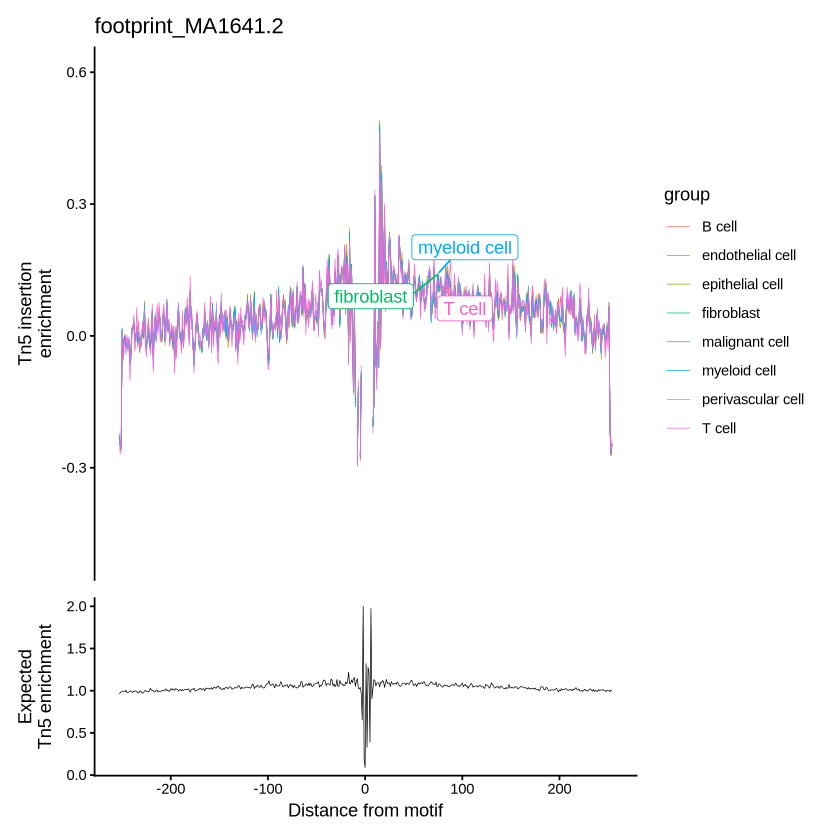

In [35]:
p

In [36]:
key <- "footprint_MA1641.2"
p <- Signac::PlotFootprint(
  object = spot_obj_out,
  features = key,
  group.by = "leiden",
  show.expected = TRUE,
  normalization = "subtract"
)

Warning message:
“Removed 5080 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


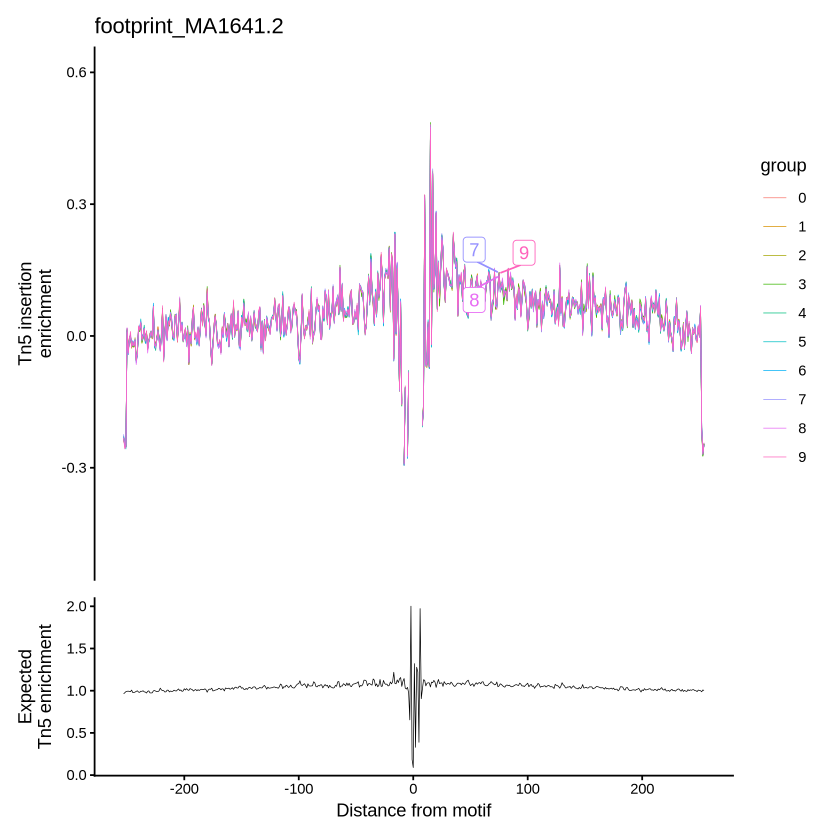

In [37]:
p

In [93]:
str(spot_obj_out[["peaks"]],max.level = 2)

Formal class 'ChromatinAssay' [package "Signac"] with 16 slots
  ..@ ranges            :Formal class 'GRanges' [package "GenomicRanges"] with 7 slots
  ..@ motifs            :Formal class 'Motif' [package "Signac"] with 5 slots
  ..@ fragments         : list()
  ..@ seqinfo           : NULL
  ..@ annotation        :Formal class 'GRanges' [package "GenomicRanges"] with 7 slots
  ..@ bias              : NULL
  ..@ positionEnrichment:List of 1
  ..@ links             :Formal class 'GRanges' [package "GenomicRanges"] with 7 slots
  ..@ counts            :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  ..@ data              :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  ..@ scale.data        : num[0 , 0 ] 
  ..@ assay.orig        : NULL
  ..@ var.features      : logi(0) 
  ..@ meta.features     :'data.frame':	165040 obs. of  0 variables
  ..@ misc              : Named list()
  ..@ key               : chr "peaks_"


In [38]:
spot_obj_out@meta.data$is_Endothelial <-
  spot_obj_out@meta.data$cell_type == "endothelial cell"

In [39]:
table(spot_obj_out@meta.data$is_Endothelial, useNA = "ifany")


FALSE  TRUE 
 1439     9 

In [40]:
table(spot_obj_out@meta.data$cell_type)


           B cell  endothelial cell   epithelial cell        fibroblast 
              646                 9                14               237 
   malignant cell      myeloid cell perivascular cell            T cell 
               81               455                 4                 2 

Warning message:
“Removed 1016 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


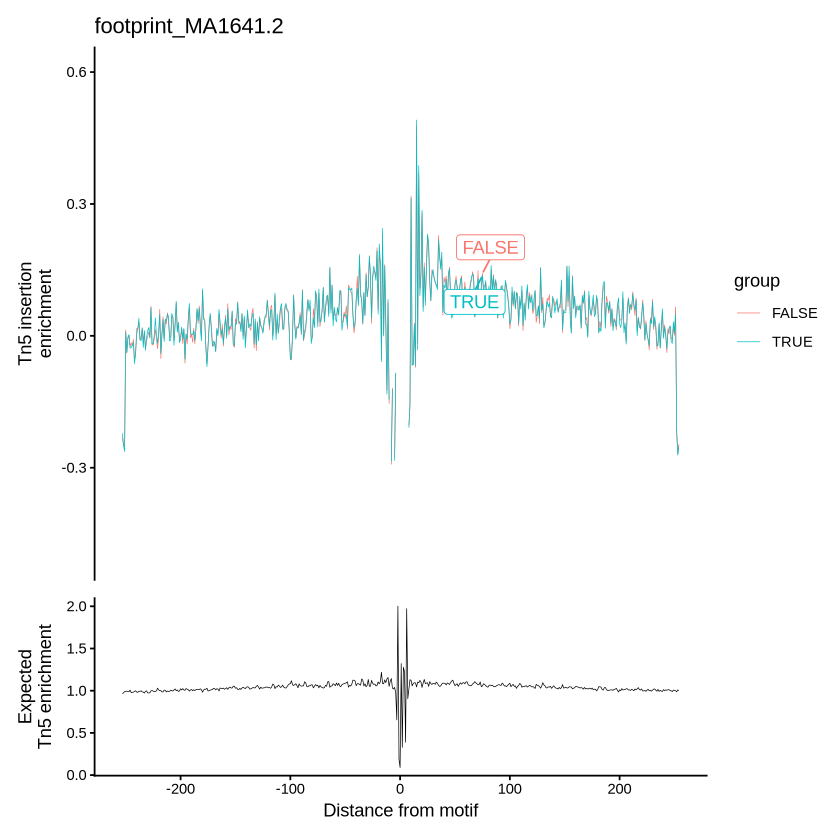

In [41]:
key <- "footprint_MA1641.2"
p <- Signac::PlotFootprint(
  object = spot_obj_out,
  features = key,
  group.by = "is_Endothelial",
  show.expected = TRUE,
  normalization = "subtract"
)
p

## another motif

In [ ]:
MA0861.2 maglinant

In [46]:
start <- Sys.time()

p <- plot_footprint_for_motif(
  motif_name = "MA0861.2",#"MA1641.2"), #"MA0144.3",
  M=M, # eg adata_map.X.csv
  spot_obj=test2,
  object_dissociated = object,
  assay = "peaks",
  clustering_var = "cell_type",
  object_dissociated_out_path = "dissociated_obj_out.rds",
  spot_obj_out_path = "spot_obj_out.rds",
  plot_out_path = "test.pdf",
  overwrite = TRUE
) 
end <- Sys.time()
print(end - start)

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Warning message:
“Removed 4128 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


Time difference of 8.579581 mins


Warning message:
“Removed 4128 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


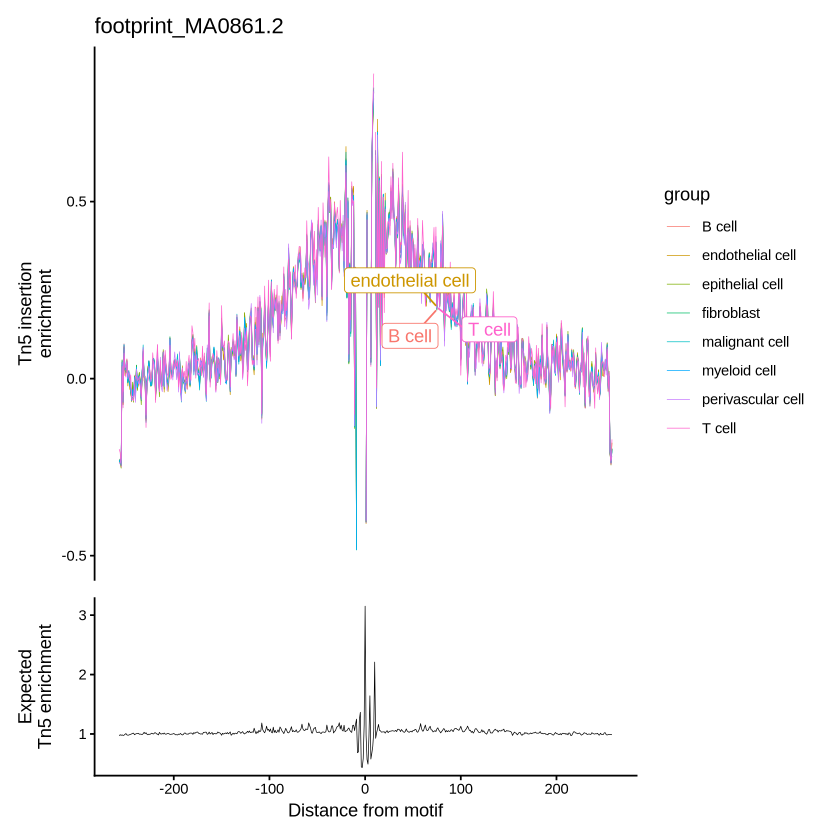

In [47]:
p 

In [48]:
spot_obj_out <-readRDS("spot_obj_out.rds")

In [49]:
str(spot_obj_out[["peaks"]]@positionEnrichment,max.level = 1 )

List of 1
 $ footprint_MA0861.2:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots


Warning message:
“Removed 5160 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


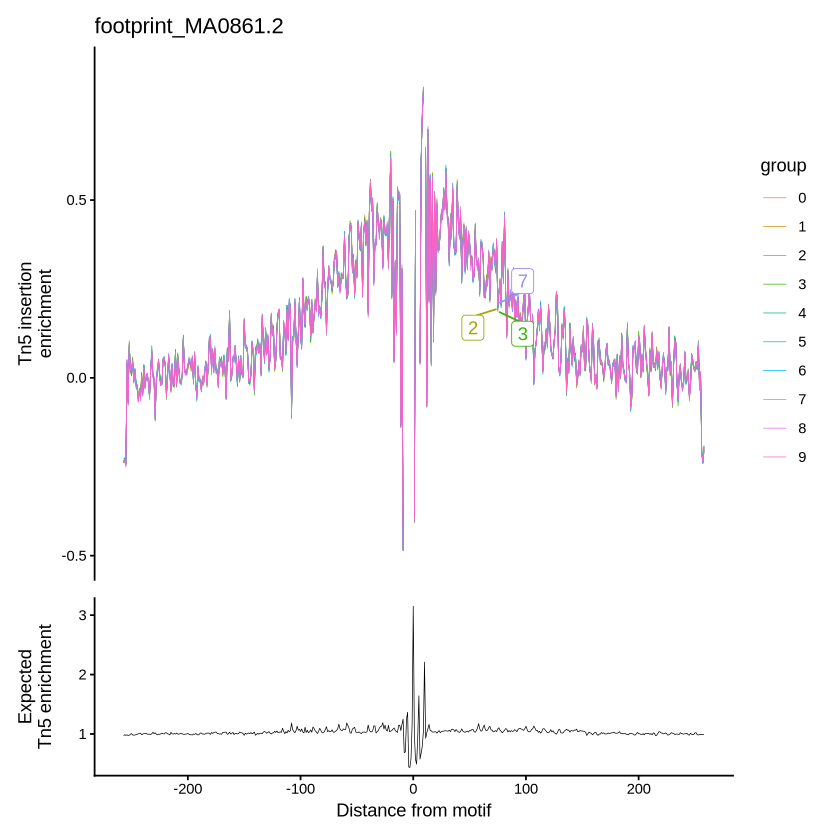

In [50]:
key <- "footprint_MA0861.2"
p <- Signac::PlotFootprint(
  object = spot_obj_out,
  features = key,
  group.by = "leiden",
  show.expected = TRUE,
  normalization = "subtract"
)
p

In [52]:
spot_obj_out@meta.data$is_Malignant <-
  spot_obj_out@meta.data$cell_type == "malignant cell"

Warning message:
“Removed 1032 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


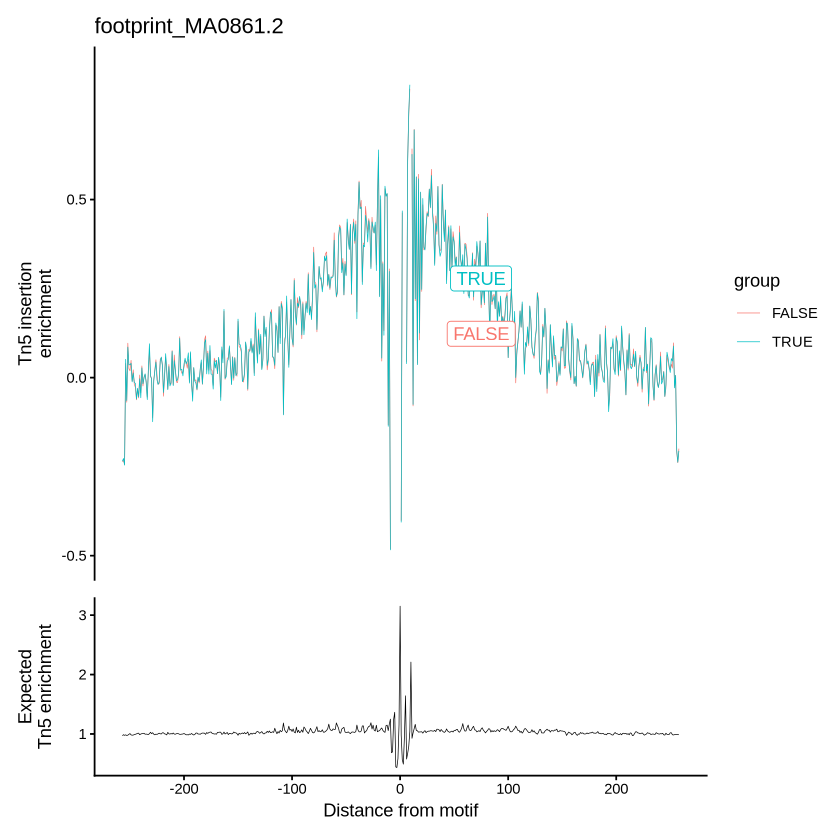

In [53]:
key <- "footprint_MA0861.2"
p <- Signac::PlotFootprint(
  object = spot_obj_out,
  features = key,
  group.by = "is_Malignant",
  show.expected = TRUE,
  normalization = "subtract"
)
p

In [54]:
object

An object of class Seurat 
202361 features across 5220 samples within 3 assays 
Active assay: peaks (165040 features, 165038 variable features)
 2 layers present: counts, data
 2 other assays present: RNA, chromvar
 5 dimensional reductions calculated: pca_sct, pca_rna, lsi, umap_RNA_peaks, umap_SCT_peaks

# another one

In [5]:
spot_obj_out <-readRDS("spot_obj_out.rds")
dis_obj_out <-readRDS("dissociated_obj_out.rds")

In [56]:
str(spot_obj_out[["peaks"]]@positionEnrichment,max.level = 1 )

List of 1
 $ footprint_MA0861.2:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots


In [59]:
start <- Sys.time()

p <- plot_footprint_for_motif(
  motif_name = "MA0144.3",#"MA0861.2",#"MA1641.2"), "MA0144.3",
  M=M, # eg adata_map.X.csv
  spot_obj=spot_obj_out,
  object_dissociated = dis_obj_out,
  assay = "peaks",
  clustering_var = "cell_type",
  object_dissociated_out_path = "dissociated_obj_out.rds",
  spot_obj_out_path = "spot_obj_out.rds",
  plot_out_path = "test.pdf",
  overwrite = TRUE
) 
end <- Sys.time()
print(end - start)

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Warning message:
“Removed 4072 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


Time difference of 9.572395 mins


Warning message:
“Removed 4072 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


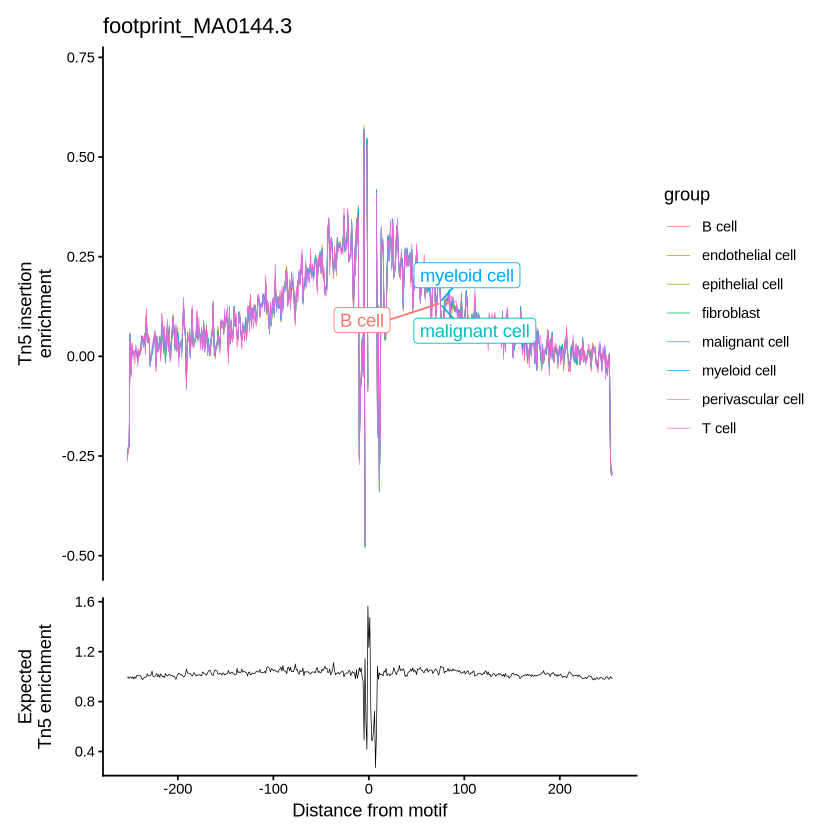

In [60]:
p

In [61]:
spot_obj_out <-readRDS("spot_obj_out.rds")

In [62]:
str(spot_obj_out[["peaks"]]@positionEnrichment,max.level = 1 )

List of 2
 $ footprint_MA0861.2:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ footprint_MA0144.3:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots


Warning message:
“Removed 5160 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


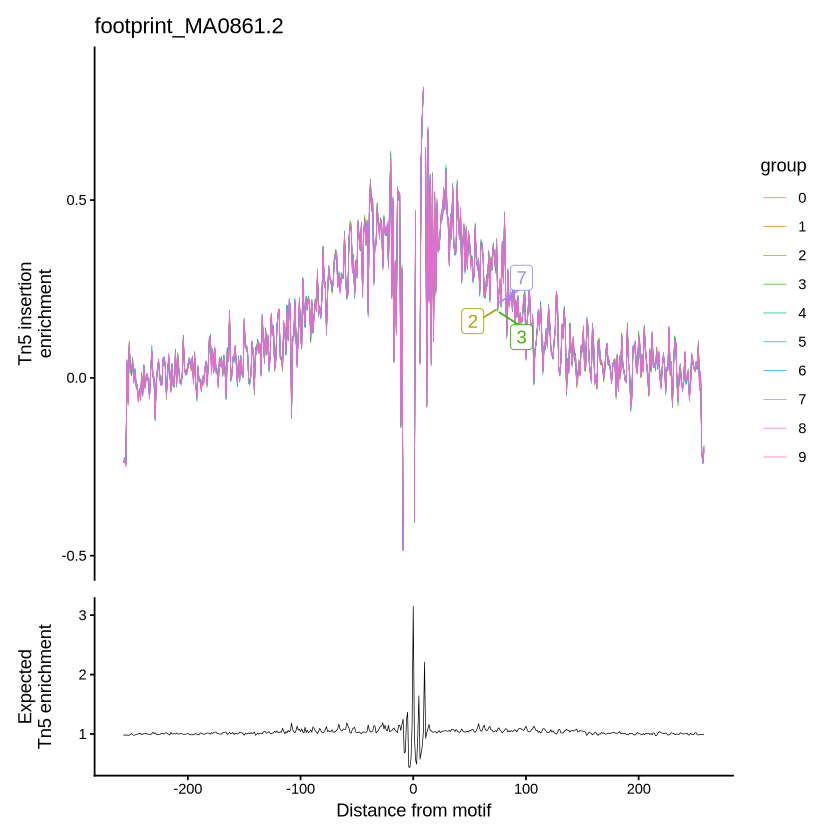

In [64]:
key <- "footprint_MA0861.2"
p <- Signac::PlotFootprint(
  object = spot_obj_out,
  features = key,
  group.by = "leiden",
  show.expected = TRUE,
  normalization = "subtract"
)
p

# another motif, that was differential in og data: MA0106.3

In [9]:
dis_obj_out <- Footprint(
  object = dis_obj_out,
  motif.name = c("MA0106.3"),
  genome = BSgenome.Hsapiens.UCSC.hg38
)

# plot the footprint data for each group of cells
p <- PlotFootprint(dis_obj_out, features = c("MA0106.3"))

Computing observed Tn5 insertions per base



Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites



Warning message:
“Removed 5180 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


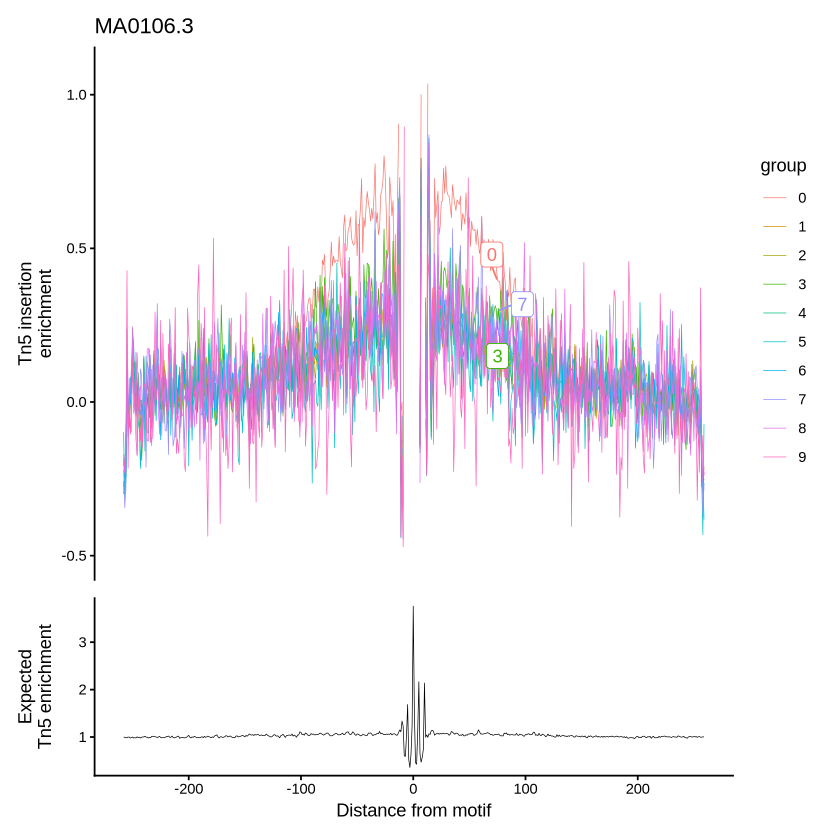

In [10]:
p

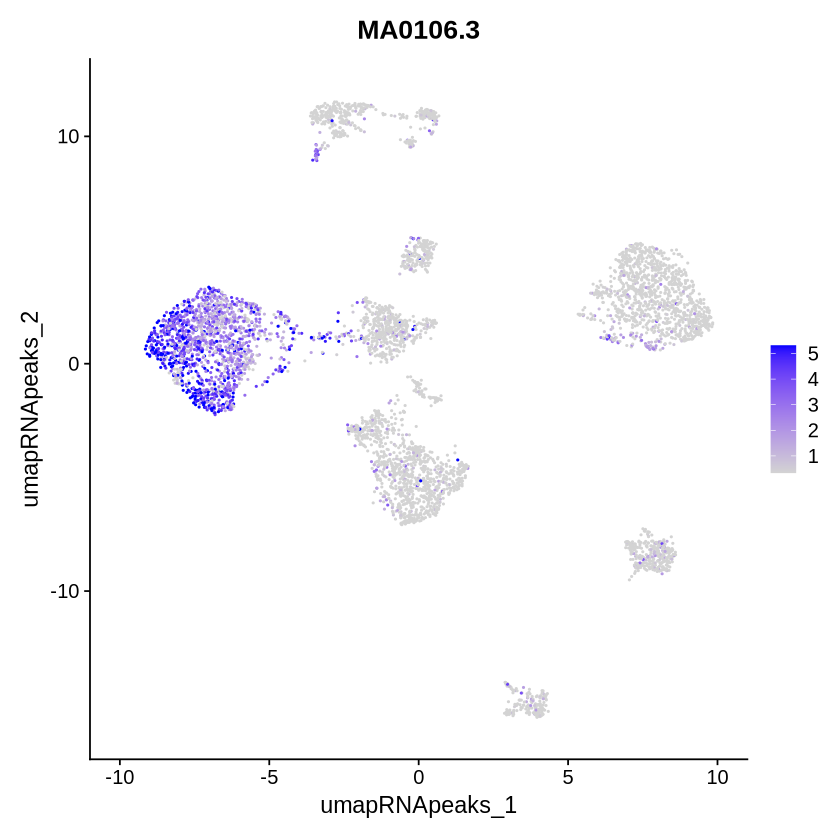

In [12]:
DefaultAssay(dis_obj_out) <- 'chromvar'

# look at the activity of Mef2c
FeaturePlot(
  object = dis_obj_out,
  features = "MA0106.3",
  min.cutoff = 'q10',
  max.cutoff = 'q90',
  pt.size = 0.1
)

In [26]:
DefaultAssay(dis_obj_out) <- 'peaks'

In [27]:
start <- Sys.time()

p <- plot_footprint_for_motif(
  motif_name = "MA0106.3",#"MA0861.2",#"MA1641.2"), "MA0144.3",
  M=M, # eg adata_map.X.csv
  spot_obj=spot_obj_out,
  object_dissociated = dis_obj_out,
  assay = "peaks",
  clustering_var = "cell_type",
  object_dissociated_out_path = "dissociated_obj_out.rds",
  spot_obj_out_path = "spot_obj_out.rds",
  plot_out_path = "test.pdf",
  overwrite = TRUE
) 
end <- Sys.time()
print(end - start)

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Warning message:
“Removed 4144 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


Time difference of 8.917843 mins


Warning message:
“Removed 4144 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


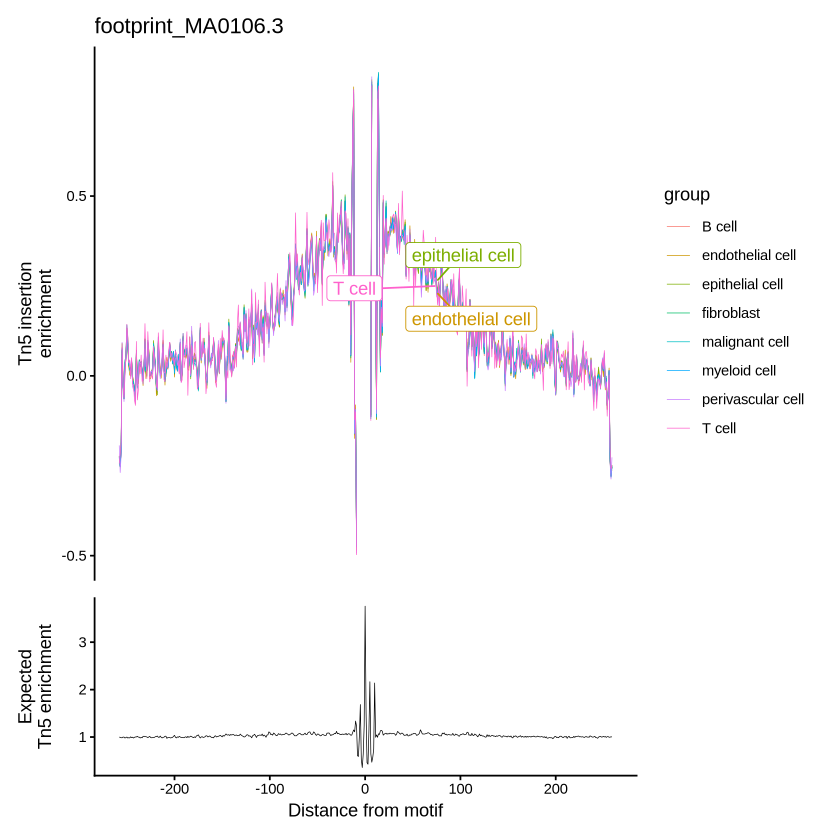

In [28]:
p

In [30]:
spot_obj_out <-readRDS("spot_obj_out.rds")

Warning message:
“Removed 5180 rows containing missing values or values outside the scale range
(`geom_label_repel()`).”


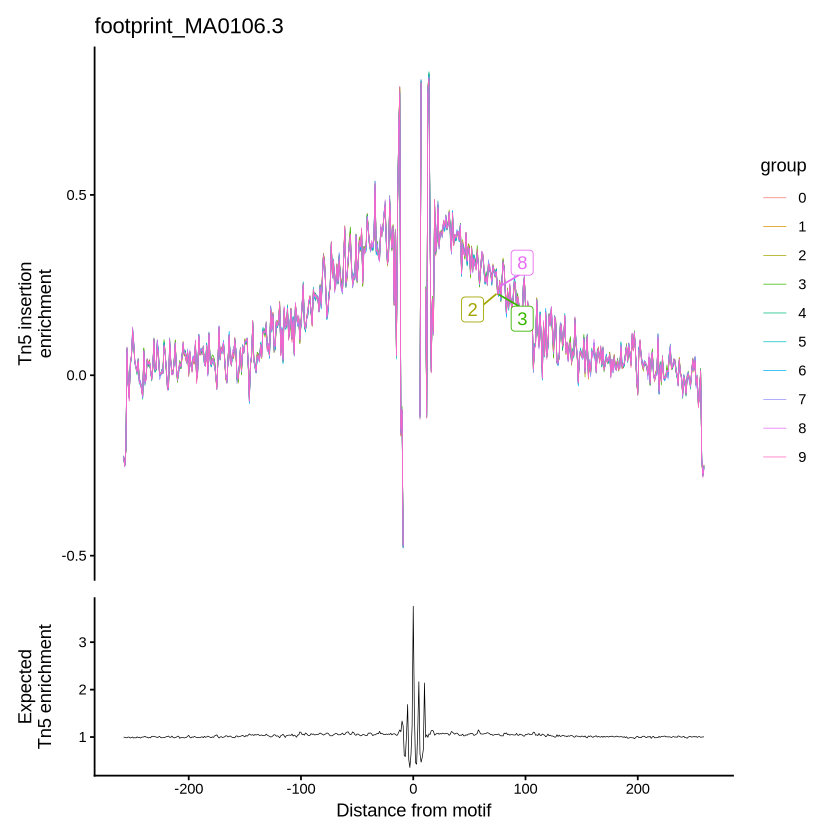

In [31]:
key <- "footprint_MA0106.3"
p <- Signac::PlotFootprint(
  object = spot_obj_out,
  features = key,
  group.by = "leiden",
  show.expected = TRUE,
  normalization = "subtract"
)
p

In [34]:
# Check available reductions
print(Reductions(spot_obj_out))


NULL


In [40]:
GetAssayData(spot_obj_out)

  [[ suppressing 33 column names ‘AAACACCAATAACTGC-1’, ‘AAACAGCTTTCAGAAG-1’, ‘AAACAGGGTCTATATT-1’ ... ]]



720 x 1448 sparse Matrix of class "dgCMatrix"
                                                                     
MA0069.1  3.82723983  1.83472320  3.53102504  2.87386905  3.169710763
MA0071.1         NaN  2.43105948  2.52667182 -2.10908754  3.769633253
MA0074.1  1.95122431         NaN  2.77157622  2.59222895          NaN
MA0101.1  2.79767395         NaN  2.74355869  3.11382042  3.677705396
MA0107.1  1.69568395         NaN  2.91077911  3.08686426  3.232091528
MA0115.1  2.07215308  3.31592005         NaN  1.71964256  1.601647914
MA0119.1  3.35599491  3.87685313  3.61861283  3.32804208  4.170386494
MA0130.1  2.20081201  2.80595720  2.90933834  2.80298533  2.489371380
MA0149.1  3.15551994  3.34295352  3.62963396  3.41465748  3.425939580
MA0155.1  3.00814968  2.50567019  3.18387563  2.59695532  2.454196703
MA0159.1  3.14667718         NaN  2.91813268  2.89301986  2.547176162
MA0163.1         NaN  3.48366417  3.10028124  3.23109210          NaN
MA0468.1         NaN         NaN  1.40180285

In [42]:
DefaultAssay(spot_obj_out) <- 'chromvar'

# Replace NaN values with 0
data_matrix <- GetAssayData(spot_obj_out, assay = 'chromvar', layer = 'counts')
data_matrix[is.nan(data_matrix)] <- 0
spot_obj_out <- SetAssayData(spot_obj_out, assay = 'chromvar', layer = 'counts', new.data = data_matrix)

# Also fix data layer
data_layer <- GetAssayData(spot_obj_out, assay = 'chromvar', layer = 'data')
data_layer[is.nan(data_layer)] <- 0
spot_obj_out <- SetAssayData(spot_obj_out, assay = 'chromvar', layer = 'data', new.data = data_layer)


In [45]:

# Debug: Check variance
data_to_check <- GetAssayData(spot_obj_out, assay = 'chromvar', layer = 'data')
cat("Data shape:", nrow(data_to_check), "x", ncol(data_to_check), "\n")
cat("Data range:", min(data_to_check), "to", max(data_to_check), "\n")
cat("Number of NaN:", sum(is.nan(data_to_check)), "\n")

# Calculate variance for each feature
feature_vars <- matrixStats::rowVars(as.matrix(data_to_check))
cat("Features with variance > 0:", sum(feature_vars > 0), "\n")
cat("Min variance:", min(feature_vars), "Max variance:", max(feature_vars), "\n")


Data shape: 720 x 1448 
Data range: -9.373818 to 9.224897 
Number of NaN: 0 
Features with variance > 0: 720 
Min variance: 0.3237673 Max variance: 2.570034 


In [51]:
mat <- GetAssayData(spot_obj_out, assay = "chromvar", layer = "data")
mat_dense <- as.matrix(mat)

pca <- prcomp(t(mat_dense), center = TRUE, scale. = FALSE)

# Put into Seurat as a DimReduc object
spot_obj_out[["pca"]] <- CreateDimReducObject(
  embeddings = pca$x[, 1:30, drop = FALSE],
  loadings   = pca$rotation[, 1:30, drop = FALSE],
  key = "PC_",
  assay = "chromvar"
)

spot_obj_out <- RunUMAP(spot_obj_out, reduction = "pca", dims = 1:30)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
10:18:14 UMAP embedding parameters a = 0.9922 b = 1.112

10:18:14 Read 1448 rows and found 30 numeric columns

10:18:14 Using Annoy for neighbor search, n_neighbors = 30

10:18:14 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:18:14 Writing NN index file to temp file /tmp/RtmpiuOBSD/file3e04675b812361

10:18:14 Searching Annoy index using 1 thread, search_k = 3000

10:18:14 Annoy recall = 100%

10:18:16 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors

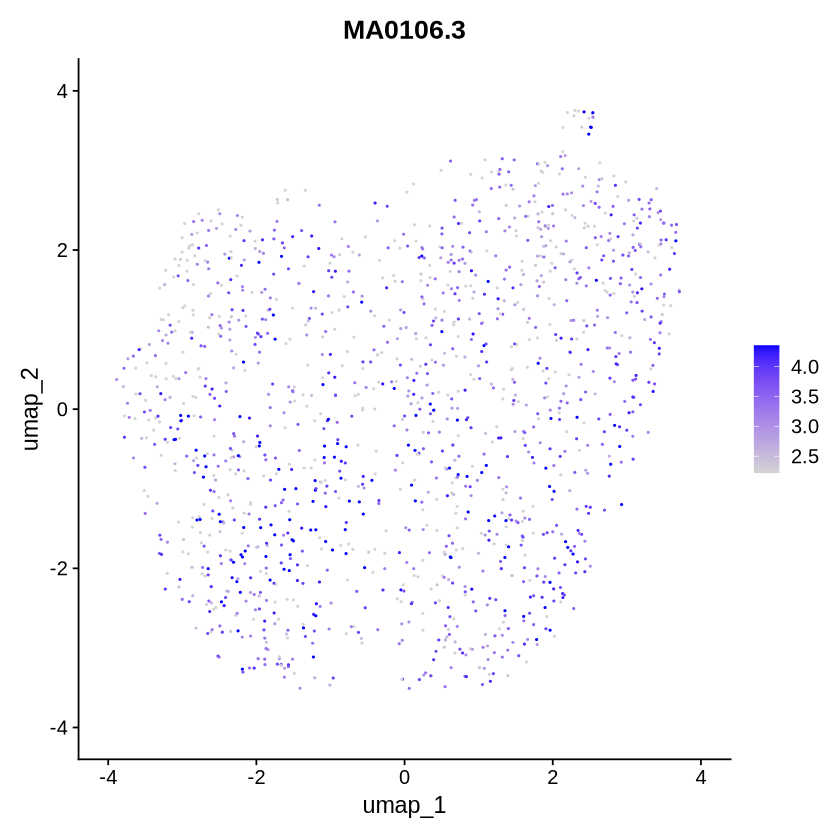

In [52]:

# look at the activity of Mef2c (MA0106.3)
FeaturePlot(
  object = spot_obj_out,
  features = "MA0106.3",
  min.cutoff = 'q10',
  max.cutoff = 'q90',
  pt.size = 0.1,
  reduction = "umap"
)

# on peaks

In [56]:
DefaultAssay(spot_obj_out) <- "peaks"

# 1) Select informative peaks
spot_obj_out <- FindTopFeatures(spot_obj_out, min.cutoff = 5)

# 2) TF-IDF normalization
spot_obj_out <- RunTFIDF(spot_obj_out)

# 3) LSI via SVD
spot_obj_out <- RunSVD(spot_obj_out)

# 4) UMAP on LSI dimensions
spot_obj_out <- RunUMAP(
  spot_obj_out,
  reduction = "lsi",
  dims = 2:30,
  reduction.name = "umap.peaks",
  reduction.key = "peaksUMAP_"
)

Performing TF-IDF normalization

Running SVD

Scaling cell embeddings

10:28:41 UMAP embedding parameters a = 0.9922 b = 1.112

10:28:41 Read 1448 rows and found 29 numeric columns

10:28:41 Using Annoy for neighbor search, n_neighbors = 30

10:28:41 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:28:41 Writing NN index file to temp file /tmp/RtmpiuOBSD/file3e046761b653fe

10:28:41 Searching Annoy index using 1 thread, search_k = 3000

10:28:41 Annoy recall = 100%

10:28:43 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

10:28:45 Initializing from normalized Laplacian + noise (using RSpectra)

10:28:46 Commencing optimization for 500 epochs, with 50608 positive edges

10:28:46 Using rng type: pcg

10:28:49 Optimization finish

Warning message:
“Could not find MA0106.3 in the default search locations, found in ‘chromvar’ assay instead”


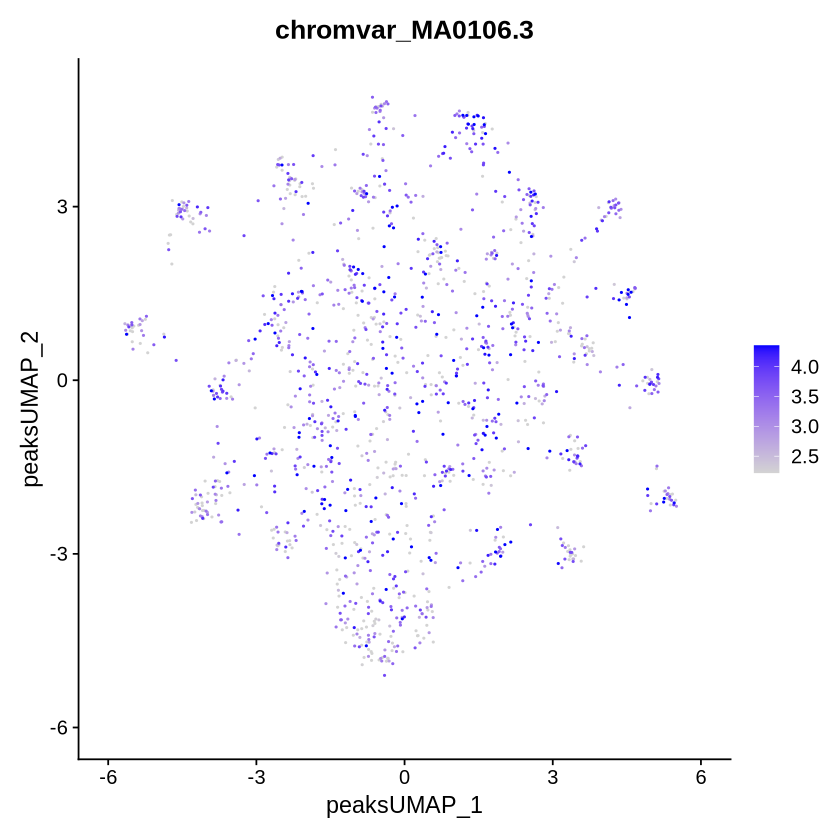

In [62]:
FeaturePlot(
  spot_obj_out,
  features = "MA0106.3",
  #assay = "chromvar",
  reduction = "umap.peaks",
  min.cutoff = "q10",
  max.cutoff = "q90",
  pt.size = 0.1,
  order = TRUE
)


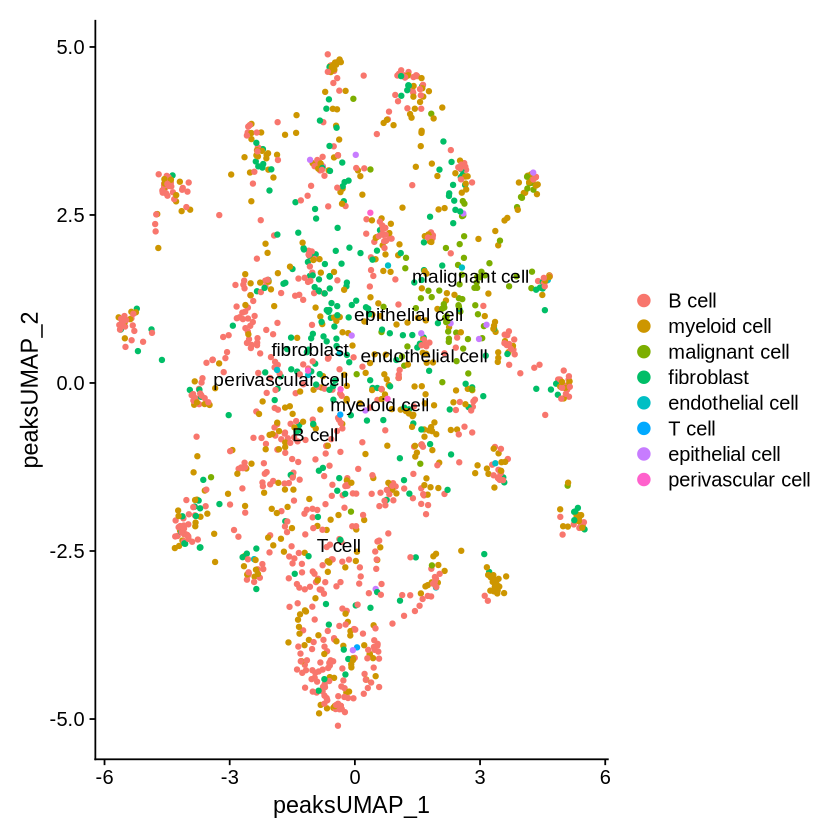

In [60]:
DimPlot(spot_obj_out, reduction = "umap.peaks", label = TRUE, repel = TRUE)

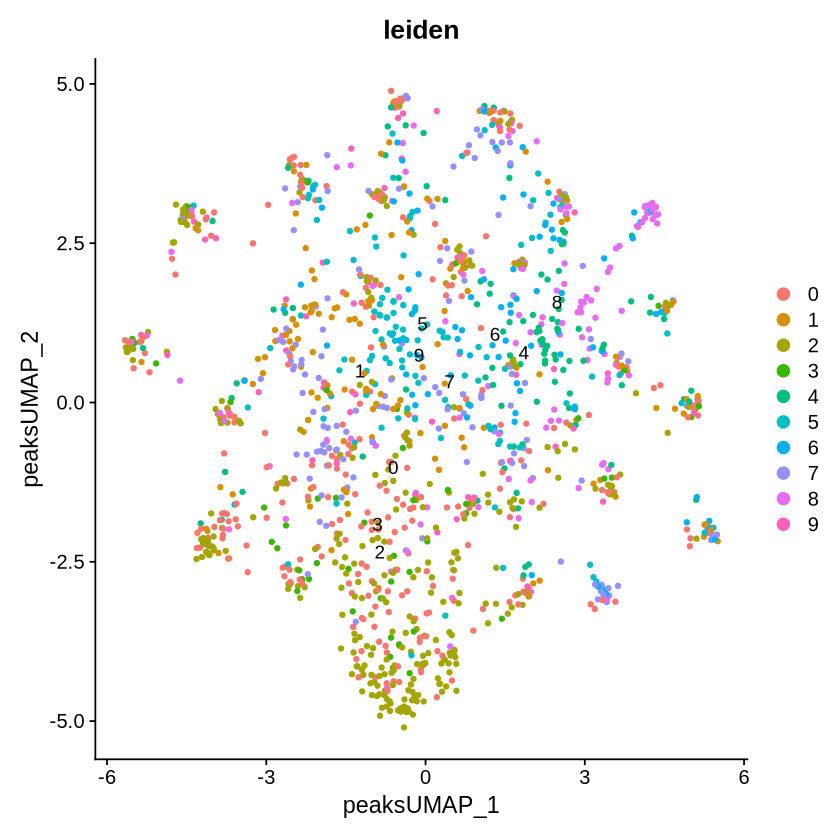

In [61]:

DimPlot(spot_obj_out, reduction = "umap.peaks", group.by = "leiden",label = TRUE, repel = TRUE)

In [63]:
spot_obj_out_new_chromvar <- RunChromVAR(
  object = spot_obj_out,
  genome = BSgenome.Hsapiens.UCSC.hg38
)

Warning message in RunChromVAR.ChromatinAssay(object = object[[assay]], genome = genome, :
“Count matrix contains non-integer values.
            ChromVAR should only be run on integer counts.”
Computing GC bias per region

Selecting background regions

Computing deviations from background

Constructing chromVAR assay

Warning message:
“Assay chromvar changing from Assay5 to Assay”
Warning message:
“Layer counts isn't present in the assay object; returning NULL”


Warning message:
“Could not find MA0106.3 in the default search locations, found in ‘chromvar’ assay instead”


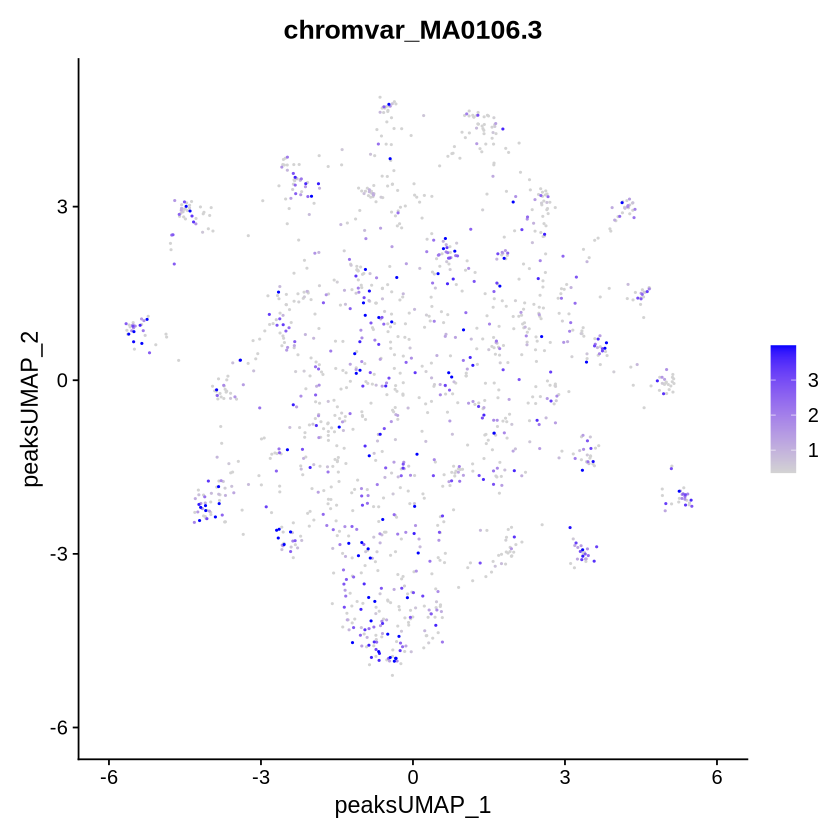

In [64]:
FeaturePlot(
  spot_obj_out_new_chromvar,
  features = "MA0106.3",
  min.cutoff = "q10",
  max.cutoff = "q90",
  pt.size = 0.1,
  order = TRUE
)

# visualize matrix

In [74]:
object@meta.data$RNA_peaks_clusters_res0.2

[1] 1 3 4 0 0 1 0 0 3 9 6 0 2 1 0 5 0 0 3 1 0 0 0 1 0 1 1 2 0 4 0 2 1 7 1 4 1
  [38] 1 5 0 0 6 1 1 4 4 2 2 6 8 3 8 1 0 1 4 8 1 0 2 1 0 4 2 3 1 0 1 6 0 1 0 2 0
  [75] 0 1 5 2 3 3 1 0 0 8 0 1 0 0 1 0 1 3 8 0 1 5 1 1 1 1 3 0 4 0 2 2 4 1 3 1 0
 [112] 5 3 0 1 4 6 0 0 2 2 0 2 0 3 3 0 2 0 4 0 0 4 0 1 0 1 5 1 3 2 0 2 2 2 2 3 0
 [149] 8 0 0 1 1 3 4 0 0 0 0 6 6 2 1 2 6 5 2 4 0 3 2 0 4 0 2 4 2 0 1 0 0 0 0 2 5
 [186] 1 2 2 0 5 1 0 0 0 0 1 2 0 4 0 8 2 0 1 0 3 0 1 2 5 2 4 0 0 2 2 1 1 1 2 2 1
 [223] 1 9 0 3 2 3 1 1 2 9 1 7 2 0 1 3 1 0 2 4 0 1 5 9 2 7 1 1 2 2 2 1 3 5 5 1 1
 [260] 4 2 1 1 0 1 1 3 4 0 6 1 0 1 4 0 1 1 1 1 2 2 0 1 2 0 3 2 7 0 8 1 3 0 2 4 0
 [297] 0 1 0 8 1 0 1 0 0 0 3 4 0 0 1 3 0 0 5 7 0 7 3 2 0 0 1 1 7 2 4 0 7 2 5 7 4
 [334] 1 0 1 3 0 0 2 9 1 3 1 9 3 3 3 2 0 4 0 1 0 0 2 1 0 2 3 0 1 1 1 0 7 0 1 1 3
 [371] 1 2 2 2 1 1 3 2 1 0 2 1 1 0 4 2 0 2 1 6 2 5 0 0 0 6 5 0 3 3 2 7 1 0 0 1 0
 [408] 4 2 2 0 2 1 0 1 0 0 0 0 0 1 4 2 1 1 5 1 1 2 2 3 1 0 4 1 1 0 3 0 3 4 1 3 4
 [445] 1 1 0 0 5 1 3 4 2 2 0 2 7 0 0 0 0 3 0 0 3 0 1 1 0 0 0 9 1 2 0 2 6 4 0 0 3
 [482] 1 0 1 0 3 2 2 3 1 1 1 0 2 0 5 1 0 0 8 0 0 0 1 0 1 0 4 2 0 1 0 0 2 1 1 6 0
 [519] 0 4 0 5 9 1 1 1 3 6 1 0 0 0 1 8 0 2 2 8 2 0 7 1 0 8 0 7 4 2 2 0 3 5 1 4 7
 [556] 3 9 0 2 2 1 0 3 0 0 2 3 2 4 0 5 2 6 0 3 0 0 2 0 0 0 1 1 7 0 8 3 0 0 2 0 2
 [593] 5 4 1 2 0 1 2 0 1 0 2 4 1 1 1 3 1 0 2 2 2 6 0 0 2 0 1 0 0 3 3 0 2 1 2 5 0
 [630] 6 1 9 1 9 8 6 3 1 4 1 2 1 7 1 0 0 1 2 3 2 1 2 2 1 1 0 1 1 3 0 0 7 0 0 0 0
 [667] 2 1 4 2 0 1 2 0 2 0 5 4 5 0 0 2 3 4 0 2 2 0 2 2 1 0 0 3 3 5 0 0 0 1 2 3 1
 [704] 1 3 9 0 1 1 3 1 1 0 5 0 5 5 2 6 0 2 1 3 2 0 0 6 1 4 0 0 0 0 2 0 7 4 3 0 0
 [741] 2 1 0 3 3 3 0 2 2 1 0 2 2 2 4 2 4 2 1 1 1 3 1 1 0 0 2 6 2 0 1 1 1 1 0 1 2
 [778] 3 1 1 2 0 0 0 3 1 0 1 1 6 2 6 1 0 2 1 1 0 0 0 0 0 1 4 0 1 5 1 2 0 7 7 2 0
 [815] 1 2 0 2 4 2 0 2 1 2 0 5 0 0 6 2 0 2 3 7 5 6 5 2 9 3 3 0 0 9 0 8 9 1 0 2 1
 [852] 0 3 2 5 4 1 1 1 3 2 0 0 0 1 2 1 0 4 1 3 1 8 1 6 1 8 0 0 2 0 1 0 2 9 1 4 5
 [889] 2 0 0 2 6 1 0 0 4 2 1 2 4 1 0 2 0 3 0 0 3 2 3 7 1 0 0 1 5 0 2 7 0 2 4 1 1
 [926] 1 0 1 0 2 6 1 1 2 3 1 1 0 2 1 4 1 0 1 2 0 2 0 2 3 0 4 0 3 0 5 4 0 0 3 0 1
 [963] 2 5 2 2 3 1 0 3 2 2 0 5 2 2 8 3 0 2 0 0 1 1 2 5 3 2 3 0 0 6 8 2 3 1 0 0 1
[1000] 1 3 1 3 6 7 0 3 2 0 4 5 0 1 2 4 7 1 0 2 1 1 2 0 1 4 0 0 0 4 0 0 0 0 0 3 1
[1037] 0 3 6 0 0 3 0 0 0 1 4 4 0 2 0 0 0 0 5 3 7 2 0 1 2 1 2 0 3 1 2 2 4 8 0 6 1
[1074] 3 1 0 2 2 1 0 0 0 2 4 2 3 6 1 3 1 0 1 1 1 3 0 6 9 7 2 5 5 1 1 7 5 3 3 5 0
[1111] 5 5 1 2 0 2 0 1 3 1 1 1 0 2 1 3 6 0 1 1 2 0 0 0 2 0 2 1 3 3 2 1 0 3 3 8 0
[1148] 5 4 7 2 5 2 2 1 1 9 0 9 0 2 0 0 3 0 5 3 1 7 1 2 4 2 2 6 3 2 2 1 9 2 4 0 0
[1185] 3 3 2 0 3 1 2 1 3 3 3 2 1 4 1 6 1 4 6 1 2 1 1 1 8 1 4 1 0 4 0 1 2 0 2 1 2
[1222] 2 1 6 6 2 0 1 1 6 3 3 1 1 0 2 0 1 3 0 5 1 3 3 0 1 3 1 1 7 0 5 3 0 0 0 3 1
[1259] 1 0 3 3 2 1 1 1 0 1 0 5 3 8 1 2 1 4 1 1 1 1 0 0 6 0 0 2 0 2 2 0 1 0 2 2 0
[1296] 0 1 1 5 9 2 3 0 1 2 3 1 0 4 3 4 3 8 0 4 1 5 0 1 0 2 1 5 2 6 0 0 1 0 2 1 2
[1333] 0 2 8 0 1 6 1 1 3 6 2 5 2 2 6 0 0 1 0 5 2 2 2 0 2 3 0 0 7 2 8 5 2 1 0 2 0
[1370] 3 2 1 3 0 1 8 9 0 0 2 2 1 2 3 1 3 3 0 0 2 0 2 1 1 0 0 4 3 1 0 2 3 3 1 3 0
[1407] 3 6 5 0 0 3 0 0 1 0 1 0 3 4 1 0 1 5 5 0 2 9 6 1 0 3 0 7 1 0 2 6 6 2 2 7 1
[1444] 1 1 9 0 1 0 3 0 5 2 1 0 2 2 1 1 1 0 0 2 1 2 3 3 3 1 1 0 2 2 4 1 4 7 2 1 6
[1481] 0 6 2 3 2 2 0 0 0 8 0 0 6 0 1 0 0 0 8 2 0 0 0 0 1 2 5 0 3 0 1 4 1 2 5 3 1
[1518] 1 6 7 3 2 1 0 0 2 1 3 2 0 5 0 1 4 0 1 0 0 0 4 0 0 0 2 8 0 4 1 2 3 1 3 4 3
[1555] 1 8 0 1 1 2 0 2 4 0 5 4 4 1 3 2 8 2 0 0 2 0 3 9 3 3 2 8 2 3 0 9 0 0 1 0 7
[1592] 4 0 1 0 0 2 0 0 1 0 1 1 2 0 1 0 2 0 0 6 0 2 2 9 9 7 5 7 2 0 2 0 2 5 0 4 9
[1629] 2 1 0 1 8 5 2 5 3 0 0 2 4 2 8 2 0 0 1 1 0 1 2 4 2 0 2 8 1 0 4 2 1 7 0 0 3
[1666] 1 3 0 7 2 0 2 2 1 1 1 2 2 1 1 4 7 6 0 3 2 2 0 1 1 3 0 2 0 2 2 5 0 0 2 1 5
[1703] 0 0 9 0 1 0 1 6 1 1 0 1 1 3 0 3 0 1 0 2 2 2 3 2 8 1 2 0 1 1 1 0 1 2 1 2 5
[1740] 0 0 0 2 0 0 7 0 8 1 4 0 0 2 2 8 1 2 2 2 1 1 1 5 4 0 2 1 7 0 1 5 7 6 9 1 0
[1777] 3 1 3 2 2 1 1 2 0 7 3 8 0 1 1 1 1 0 7 0 8 6 7 3 5 9 1 3 3 7 8 5 0 0 0 6 3
[1814] 1 0 0 1 1 3 0 0 6 2 0 4 1 0

In [72]:
spot_obj_out@meta.data$"cell_type"

[1] "B cell"            "myeloid cell"      "myeloid cell"     
   [4] "B cell"            "B cell"            "myeloid cell"     
   [7] "malignant cell"    "myeloid cell"      "myeloid cell"     
  [10] "myeloid cell"      "fibroblast"        "B cell"           
  [13] "B cell"            "B cell"            "malignant cell"   
  [16] "B cell"            "B cell"            "B cell"           
  [19] "fibroblast"        "B cell"            "fibroblast"       
  [22] "myeloid cell"      "myeloid cell"      "B cell"           
  [25] "B cell"            "myeloid cell"      "B cell"           
  [28] "B cell"            "myeloid cell"      "B cell"           
  [31] "B cell"            "B cell"            "fibroblast"       
  [34] "malignant cell"    "B cell"            "myeloid cell"     
  [37] "myeloid cell"      "B cell"            "myeloid cell"     
  [40] "B cell"            "B cell"            "myeloid cell"     
  [43] "fibroblast"        "B cell"            "B cell"           
  [46] "B cell"            "myeloid cell"      "fibroblast"       
  [49] "B cell"            "B cell"            "B cell"           
  [52] "B cell"            "malignant cell"    "B cell"           
  [55] "B cell"            "myeloid cell"      "myeloid cell"     
  [58] "B cell"            "B cell"            "B cell"           
  [61] "myeloid cell"      "myeloid cell"      "B cell"           
  [64] "fibroblast"        "B cell"            "myeloid cell"     
  [67] "B cell"            "malignant cell"    "myeloid cell"     
  [70] "B cell"            "B cell"            "myeloid cell"     
  [73] "B cell"            "B cell"            "myeloid cell"     
  [76] "myeloid cell"      "fibroblast"        "malignant cell"   
  [79] "fibroblast"        "myeloid cell"      "myeloid cell"     
  [82] "fibroblast"        "B cell"            "B cell"           
  [85] "B cell"            "fibroblast"        "fibroblast"       
  [88] "B cell"            "myeloid cell"      "myeloid cell"     
  [91] "myeloid cell"      "endothelial cell"  "B cell"           
  [94] "B cell"            "malignant cell"    "fibroblast"       
  [97] "fibroblast"        "myeloid cell"      "myeloid cell"     
 [100] "B cell"            "B cell"            "myeloid cell"     
 [103] "myeloid cell"      "malignant cell"    "B cell"           
 [106] "myeloid cell"      "fibroblast"        "myeloid cell"     
 [109] "B cell"            "myeloid cell"      "B cell"           
 [112] "B cell"            "myeloid cell"      "fibroblast"       
 [115] "B cell"            "B cell"            "myeloid cell"     
 [118] "B cell"            "B cell"            "B cell"           
 [121] "fibroblast"        "myeloid cell"      "myeloid cell"     
 [124] "myeloid cell"      "B cell"            "B cell"           
 [127] "malignant cell"    "B cell"            "B cell"           
 [130] "B cell"            "B cell"            "B cell"           
 [133] "fibroblast"        "B cell"            "fibroblast"       
 [136] "B cell"            "myeloid cell"      "B cell"           
 [139] "myeloid cell"      "B cell"            "myeloid cell"     
 [142] "B cell"            "myeloid cell"      "B cell"           
 [145] "B cell"            "B cell"            "fibroblast"       
 [148] "malignant cell"    "myeloid cell"      "fibroblast"       
 [151] "B cell"            "malignant cell"    "myeloid cell"     
 [154] "fibroblast"        "B cell"            "myeloid cell"     
 [157] "myeloid cell"      "B cell"            "fibroblast"       
 [160] "malignant cell"    "myeloid cell"      "B cell"           
 [163] "myeloid cell"      "fibroblast"        "myeloid cell"     
 [166] "myeloid cell"      "B cell"            "fibroblast"       
 [169] "myeloid cell"      "B cell"            "B cell"           
 [172] "B cell"            "fibroblast"        "B cell"           
 [175] "B cell"            "fibroblast"        "B cell"           
 [178] "B cell"            "B cell"            "B 

In [87]:
M

,AAACACCAATAACTGC.1,AAACAGCTTTCAGAAG.1,AAACAGGGTCTATATT.1,AAACCGGGTAGGTACC.1,AAACCTCATGAAGTTG.1,AAACGAAGATGGAGTA.1,AAACTGCTGGCTCCAA.1,AAACTTGCAAACGTAT.1,AAAGAATGACCTTAGA.1,AAAGACTGGGCGCTTT.1,⋯,TTGTCGTTCAGTTACC.1,TTGTGAACCTAATCCG.1,TTGTGCAGCCACGTCA.1,TTGTGGTAGGAGGGAT.1,TTGTGTATGCCACCAA.1,TTGTGTTTCCCGAAAG.1,TTGTTAGCAAATTCGA.1,TTGTTCAGTGTGCTAC.1,TTGTTTCACATCCAGG.1,TTGTTTCCATACAACT.1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAACAGCCAAACTAAG-1,5.227574e-06,4.848739e-06,1.669438e-05,6.662484e-06,1.668345e-05,2.228696e-06,6.135520e-05,1.277638e-05,2.083448e-06,4.089793e-04,⋯,3.664686e-03,1.434782e-03,9.486074e-06,1.237069e-05,3.236438e-03,8.415554e-04,2.427854e-03,1.547631e-05,1.441785e-05,3.608286e-04
AAACAGCCAAAGCTAA-1,7.399560e-06,5.024100e-06,2.128551e-05,5.704126e-04,1.733352e-05,4.422825e-06,6.772465e-06,1.030796e-04,2.892505e-06,6.082389e-06,⋯,2.005481e-03,1.498013e-04,7.795153e-06,4.381574e-04,7.538990e-04,1.320424e-05,4.179139e-04,1.028254e-05,1.152070e-04,1.224720e-03
AAACAGCCACCTAATG-1,4.746504e-06,1.854009e-05,2.277018e-04,9.741744e-04,1.099698e-04,1.889415e-04,3.663720e-05,6.867933e-05,7.644730e-06,3.451838e-03,⋯,1.560467e-04,5.186977e-05,5.058177e-03,2.027650e-05,3.615397e-04,2.130295e-05,2.789105e-04,1.224378e-05,1.603374e-05,1.880573e-04
AAACATGCAAACATAG-1,2.898189e-03,3.049108e-04,1.824268e-04,3.153012e-04,1.453625e-05,2.479866e-06,1.803750e-05,1.942469e-03,5.573125e-06,6.311704e-06,⋯,6.189646e-04,3.398282e-04,7.422982e-06,9.565627e-06,2.934240e-04,2.772054e-05,1.393805e-04,4.156679e-06,1.458180e-04,1.661762e-03
AAACATGCACAAGCCT-1,4.689275e-03,3.017918e-06,4.557201e-06,7.634121e-06,9.006918e-06,8.465324e-04,8.709564e-05,3.702899e-05,2.656975e-03,3.554207e-06,⋯,3.324985e-03,1.812958e-03,8.976699e-06,3.441785e-06,3.159822e-03,1.467052e-03,6.611329e-04,3.208692e-05,9.173416e-06,1.298995e-04
AAACATGCACATAACT-1,9.849595e-06,3.155401e-04,1.819263e-04,6.414097e-06,3.971958e-04,5.678209e-06,4.378105e-05,8.846305e-06,1.995734e-06,6.683030e-05,⋯,1.177475e-03,6.415566e-03,6.924995e-06,6.767217e-05,8.483513e-05,3.029964e-06,3.315077e-03,9.271821e-05,9.920415e-06,2.187316e-05
AAACATGCACTAAATC-1,7.372042e-06,1.550121e-05,1.189948e-05,3.237836e-03,5.039995e-05,1.504216e-03,2.732502e-05,1.245747e-05,6.821613e-03,9.896284e-05,⋯,3.781767e-03,7.524528e-05,4.906793e-03,8.103629e-05,1.784311e-05,1.090384e-04,7.648367e-05,2.049875e-06,9.022978e-06,1.601925e-05
AAACATGCACTAAGAA-1,4.279241e-06,1.984428e-06,3.045597e-05,1.499053e-04,9.625888e-03,1.461470e-05,7.163084e-05,1.285144e-05,2.850089e-06,7.947400e-06,⋯,2.375373e-04,5.651422e-05,1.521096e-03,2.604169e-06,1.346644e-05,1.742275e-05,6.541419e-05,4.301118e-06,1.043930e-03,1.100492e-05
AAACATGCATAAACCT-1,7.202743e-06,4.253529e-05,1.766350e-05,2.712200e-05,7.303354e-04,2.627176e-06,3.929205e-03,1.873850e-03,1.522848e-05,1.042623e-04,⋯,2.482492e-03,3.781456e-04,1.789300e-06,5.384628e-05,1.254649e-03,6.774163e-06,1.442003e-04,3.627061e-03,3.459562e-04,1.167815e-04


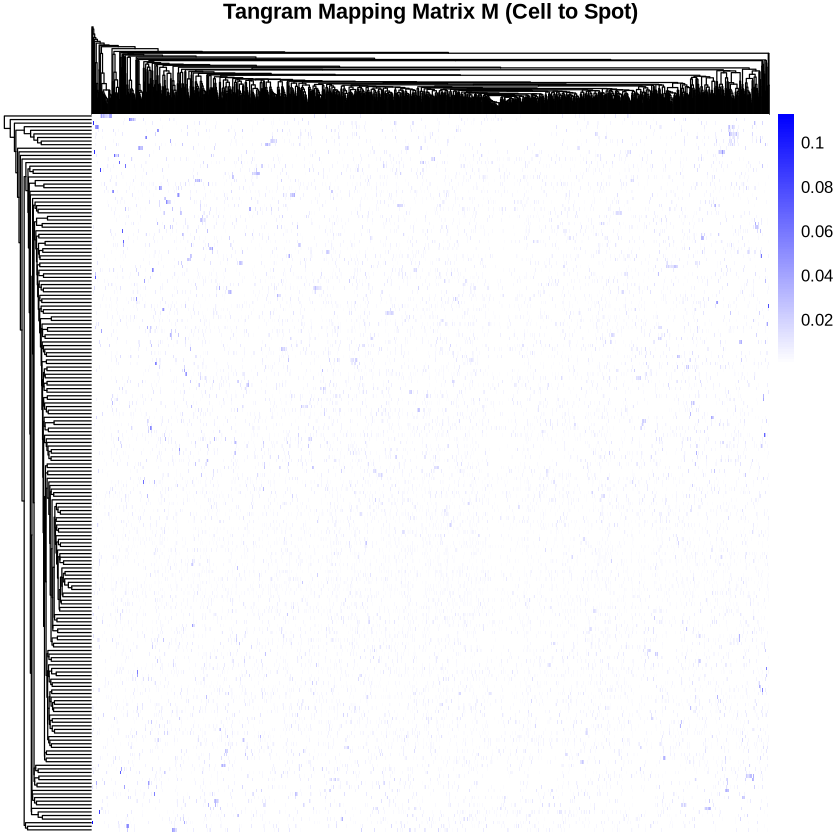

In [4]:
# Simple heatmap for M (cell-to-cell mapping)
library(pheatmap)

pheatmap(
  M[0:200, ],
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  show_rownames = FALSE,
  show_colnames = FALSE,
  main = "Tangram Mapping Matrix M (Cell to Spot)",
  color = colorRampPalette(c("white", "blue"))(100)
)

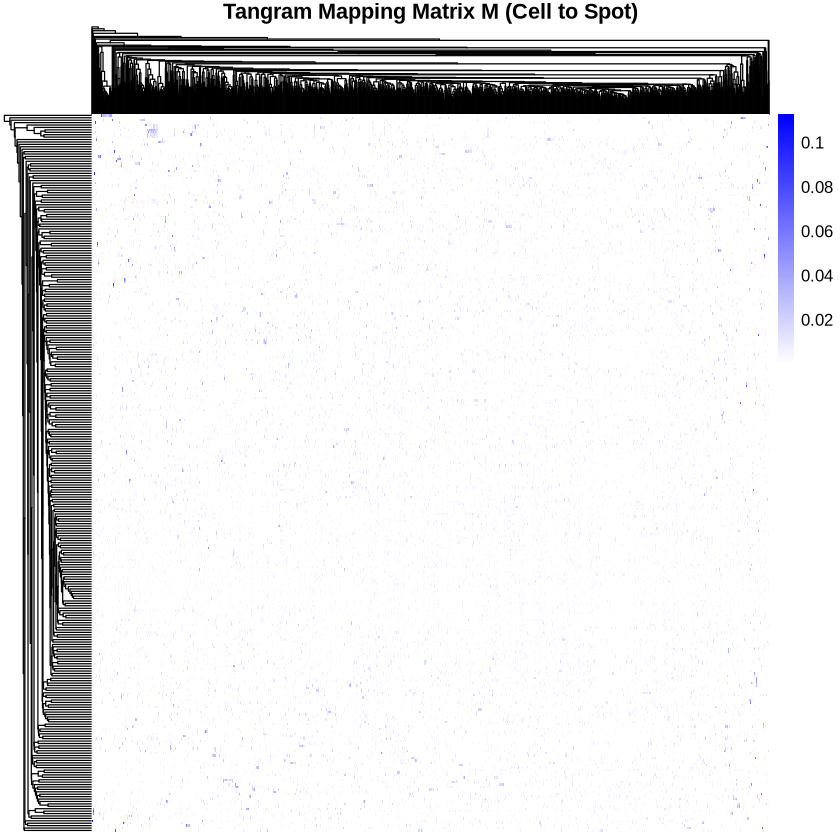

In [3]:
# Simple heatmap for M (cell-to-cell mapping)
library(pheatmap)

pheatmap(
  M,
  cluster_rows = TRUE,
  cluster_cols = TRUE,
  show_rownames = FALSE,
  show_colnames = FALSE,
  main = "Tangram Mapping Matrix M (Cell to Spot)",
  color = colorRampPalette(c("white", "blue"))(100)
)

In [86]:
M_mat

,B cell,myeloid cell,myeloid cell,B cell,B cell,myeloid cell,malignant cell,myeloid cell,myeloid cell,myeloid cell,⋯,B cell,myeloid cell,B cell,malignant cell,B cell,B cell,myeloid cell,fibroblast,B cell,B cell
1,5.227574e-06,4.848739e-06,1.669438e-05,6.662484e-06,1.668345e-05,2.228696e-06,6.135520e-05,1.277638e-05,2.083448e-06,4.089793e-04,⋯,3.664686e-03,1.434782e-03,9.486074e-06,1.237069e-05,3.236438e-03,8.415554e-04,2.427854e-03,1.547631e-05,1.441785e-05,3.608286e-04
3,7.399560e-06,5.024100e-06,2.128551e-05,5.704126e-04,1.733352e-05,4.422825e-06,6.772465e-06,1.030796e-04,2.892505e-06,6.082389e-06,⋯,2.005481e-03,1.498013e-04,7.795153e-06,4.381574e-04,7.538990e-04,1.320424e-05,4.179139e-04,1.028254e-05,1.152070e-04,1.224720e-03
4,4.746504e-06,1.854009e-05,2.277018e-04,9.741744e-04,1.099698e-04,1.889415e-04,3.663720e-05,6.867933e-05,7.644730e-06,3.451838e-03,⋯,1.560467e-04,5.186977e-05,5.058177e-03,2.027650e-05,3.615397e-04,2.130295e-05,2.789105e-04,1.224378e-05,1.603374e-05,1.880573e-04
0,2.898189e-03,3.049108e-04,1.824268e-04,3.153012e-04,1.453625e-05,2.479866e-06,1.803750e-05,1.942469e-03,5.573125e-06,6.311704e-06,⋯,6.189646e-04,3.398282e-04,7.422982e-06,9.565627e-06,2.934240e-04,2.772054e-05,1.393805e-04,4.156679e-06,1.458180e-04,1.661762e-03
0,4.689275e-03,3.017918e-06,4.557201e-06,7.634121e-06,9.006918e-06,8.465324e-04,8.709564e-05,3.702899e-05,2.656975e-03,3.554207e-06,⋯,3.324985e-03,1.812958e-03,8.976699e-06,3.441785e-06,3.159822e-03,1.467052e-03,6.611329e-04,3.208692e-05,9.173416e-06,1.298995e-04
1,9.849595e-06,3.155401e-04,1.819263e-04,6.414097e-06,3.971958e-04,5.678209e-06,4.378105e-05,8.846305e-06,1.995734e-06,6.683030e-05,⋯,1.177475e-03,6.415566e-03,6.924995e-06,6.767217e-05,8.483513e-05,3.029964e-06,3.315077e-03,9.271821e-05,9.920415e-06,2.187316e-05
0,7.372042e-06,1.550121e-05,1.189948e-05,3.237836e-03,5.039995e-05,1.504216e-03,2.732502e-05,1.245747e-05,6.821613e-03,9.896284e-05,⋯,3.781767e-03,7.524528e-05,4.906793e-03,8.103629e-05,1.784311e-05,1.090384e-04,7.648367e-05,2.049875e-06,9.022978e-06,1.601925e-05
0,4.279241e-06,1.984428e-06,3.045597e-05,1.499053e-04,9.625888e-03,1.461470e-05,7.163084e-05,1.285144e-05,2.850089e-06,7.947400e-06,⋯,2.375373e-04,5.651422e-05,1.521096e-03,2.604169e-06,1.346644e-05,1.742275e-05,6.541419e-05,4.301118e-06,1.043930e-03,1.100492e-05
3,7.202743e-06,4.253529e-05,1.766350e-05,2.712200e-05,7.303354e-04,2.627176e-06,3.929205e-03,1.873850e-03,1.522848e-05,1.042623e-04,⋯,2.482492e-03,3.781456e-04,1.789300e-06,5.384628e-05,1.254649e-03,6.774163e-06,1.442003e-04,3.627061e-03,3.459562e-04,1.167815e-04
9,3.014195e-03,5.012386e-06,1.539600e-05,3.285047e-04,5.814802e-06,4.549404e-05,5.049734e-05,8.732012e-05,2.175767e-04,5.392987e-03,⋯,1.451853e-04,3.272264e-05,4.398709e-06,1.752500e-03,3.528687e-05,1.304908e-03,1.561538e-03,2.122184e-05,9.294198e-05,7.635116e-05


In [83]:
row_labels <- object@meta.data$RNA_peaks_clusters_res0.2
col_labels <- spot_obj_out@meta.data$"cell_type"
rownames(M_mat) <- row_labels
colnames(M_mat) <- col_labels

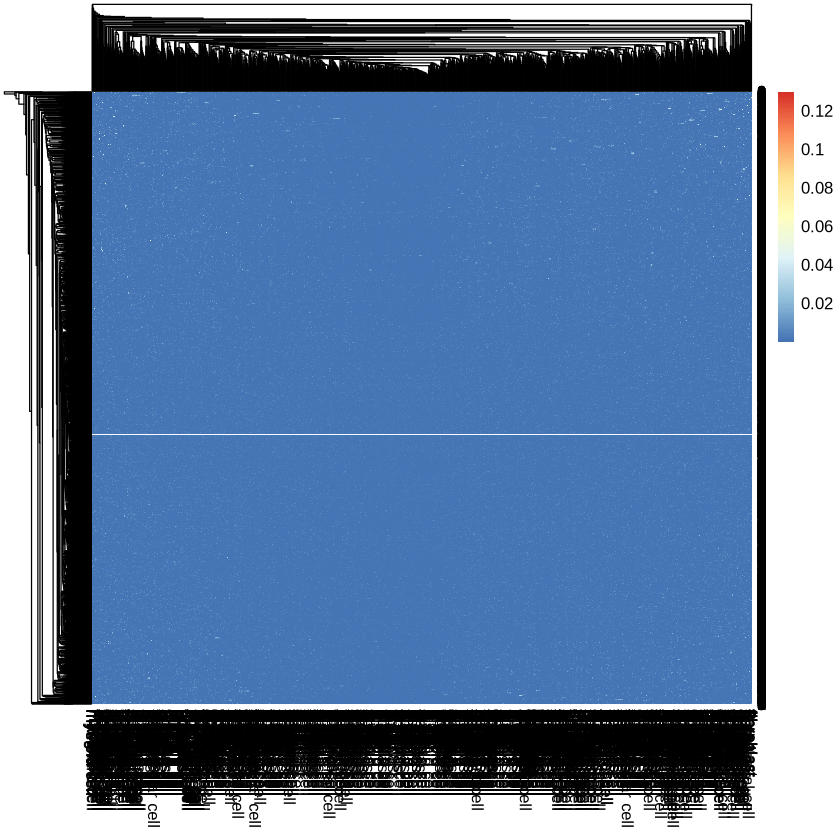

In [85]:
# make heatmap grouped by row and column labels
library(pheatmap)
pheatmap::pheatmap(M_mat, cluster_rows = TRUE, cluster_cols = TRUE, show_rownames = TRUE, show_colnames = TRUE)
 